# MVP — Machine Learning & Analytics

**Nome:** _Mylena de Amorim Delfino_  
**Matrícula:** _4052026001042_  
**Data:** _02/07/2026_  
**Datasets:**
- [São Paulo Real Estate Sales and Rentals 2020-2026 (bairro_prices_monthly.csv)](https://www.kaggle.com/datasets/sergionefedov/so-paulo-real-estate-sales-and-rentals-2020-2026)
- [Sao Paulo Geospatial features (tb_neighborhood.parquet)](https://www.kaggle.com/datasets/mateuspicanco/sao-paulo-geospatial-features)

**Tipo de problema:** Regressão e clusterização


# 1. Definição do problema

## 1.1 Descrição do problema
O preço do aluguel na cidade de São Paulo varia significativamente entre os bairros e é influenciado por diversos fatores. O objetivo deste trabalho é compreender se características demográficas (e.g. renda média das famílias) e geográficas (e.g. presença de áreas verdes) ajudam a explicar o preço médio do aluguel por bairro e identificar bairros com perfis semelhantes por meio de técnicas de clusterização.

Além de permitir a previsão do preço médio do aluguel para apoiar decisões comerciais, os resultados da análise também podem contribuir para a identificação de padrões urbanos e subsidiar políticas públicas voltadas para populações mais vulneráveis.

## 1.2 Objetivo do MVP

**Objetivos deste trabalho:**  
- Construir e comparar diferentes modelos de regressão para prever o preço médio do aluguel por bairro a partir de características demográficas.
- Avaliar se as características demográficas possuem capacidade preditiva para explicar o preço médio do aluguel, comparando o desempenho dos modelos com um baseline.
- Identificar grupos de bairros com perfis demográficos semelhantes por meio de técnicas de clusterização e comparar os agrupamentos obtidos com os tiers existentes no dataset.


## 1.3 Tipo de problema

**Tipo escolhido:** _Regressão supervisionada e clusterização não supervisionada._  
**Justificativa:** _A regressão foi utilizada para prever o preço médio do aluguel por bairro a partir de características demográficas e geográficas. A clusterização foi utilizada para identificar grupos de bairros com perfis semelhantes e analisar se esses agrupamentos apresentam relação com os tiers e os diferentes níveis de preço do aluguel._

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. _Características demográficas ajudam a explicar e prever o preço médio do aluguel por bairro na cidade de São Paulo._
2. _É possível agrupar bairros com perfis demográficos semelhantes por meio de técnicas de clusterização, e esses grupos apresentam padrões semelhantes de preço do aluguel._
3. _Características socioeconômicas, como renda média, estão associadas a preços médios de aluguel mais elevados._

**Critérios de sucesso:**
- Métrica principal: _RMSE para regressão e Silhouette para clusterização._
- Resultado mínimo esperado: _Superar o baseline na previsão do preço do aluguel e obter clusters coerentes com os tiers existentes no dataset._
- Restrição prática: _Modelo com baixo custo computacional, interpretável e capaz de generalizar para períodos futuros utilizando validação temporal._

# 2. Ambiente, bibliotecas e reprodutibilidade

In [23]:
!pip install kagglehub

In [24]:
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import kagglehub
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.cluster import KMeans, AgglomerativeClustering
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from scipy.stats import randint


SEED = 10

##2.1 Funções auxiliares

In [25]:
def sanity_checks(df, key_cols="neighborhood_name", target_col=None, show=True):
    total = len(df)

    #considera campos nulos e strings vazias
    missing = df.replace(r"^\s*$", pd.NA, regex=True).isna().sum()

    #cria o df
    sanity_check_df = df.dtypes.to_frame("tipo")

    #adiciona mais informações
    sanity_check_df["missing_count"] = missing
    sanity_check_df["pct_missing"] = (missing / total * 100).round(2)

    #ordena pelo percentual de valores faltantes
    sanity_check_df = sanity_check_df.sort_values(
        by="pct_missing",
        ascending=False
    )

    #adiciona uma coluna indicando a variável target
    if target_col is not None:
        sanity_check_df["target"] = sanity_check_df.index == target_col

    #garante que key_cols seja uma lista
    if isinstance(key_cols, str):
        key_cols = [key_cols]

    #conta linhas duplicadas considerando a coluna chave
    if all(col in df.columns for col in key_cols):

        dup_names = (
            df[key_cols]
            .value_counts()
            .loc[lambda s: s > 1]
        )

        dup_rows = df.duplicated(subset=key_cols).sum()

    else:
        dup_names = pd.Series(dtype=int)
        dup_rows = 0

    result = {
        "sanity_check": sanity_check_df,
        "dup_rows": dup_rows,
        "dup_names": dup_names,
    }

    if show:
        print(f"Dataset shape: {df.shape}")

        print("\nSanity check:")
        display(sanity_check_df)

        if all(col in df.columns for col in key_cols):
            if dup_names.empty:
                print(f"\nNo duplicates found for {key_cols}.")
            else:
                print(f"\nFound {dup_rows} duplicate rows considering {key_cols}:")
                display(dup_names.to_frame("count"))
        else:
            print(f"\nOne or more key columns were not found: {key_cols}")

    return result

def add_population_per_hectare(df):
    df["neighborhood_population_per_hectare"] = (
        df["neighborhood_population"]
        / df["neighborhood_area_in_hectares"]
    )
    return df


def add_properties_per_hectare(df):
    df["neighborhood_properties_per_hectare"] = (
        df["neighborhood_total_number_properties"]
        / df["neighborhood_area_in_hectares"]
    )
    return df


def add_proportion_residents_rented(df):
    df["neighborhood_proportion_residents_rented"] = (
        df["neighborhood_residents_in_rented_properties"]
        / df["neighborhood_population"]
    )
    return df


def add_proportion_park_area(df):
    df["neighborhood_proportion_park_area"] = (
        df["neighborhood_total_park_area"]
        / df["neighborhood_area_in_square_meters"]
    )
    return df


def add_proportion_favela_area(df):
    df["neighborhood_proportion_favela_area"] = (
        df["neighborhood_total_favela_area"]
        / df["neighborhood_area_in_square_meters"]
    )
    return df

def scatter_vs_target(df, feature_col, target_col="rent_per_m2_monthly_brl", alpha=0.3, figsize=(8,5)):

    plt.figure(figsize=figsize)

    plt.scatter(
        df[feature_col],
        df[target_col],
        alpha=alpha
    )

    plt.title(f"{feature_col} vs {target_col}")
    plt.xlabel(feature_col)
    plt.ylabel(target_col)
    plt.grid()
    plt.show()

def analyze_features(df, column, figsize=(12,4)):

    series = df[column].dropna()

    print("=" * 80)
    print(column)

    display(series.describe().to_frame("value"))

    print(f"Missing: {df[column].isna().sum()} ({df[column].isna().mean()*100:.2f}%)")
    print(f"Valores únicos: {series.nunique()}")

    # Outliers pelo IQR
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = series[(series < lower) | (series > upper)]

    print(f"Outliers (IQR): {len(outliers)} ({len(outliers)/len(series)*100:.2f}%)")

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].hist(series, bins=30)
    axes[0].set_title(f"Distribuição - {column}")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Frequência")
    axes[0].grid(True)

    axes[1].boxplot(series, vert=False)
    axes[1].set_title(f"Boxplot - {column}")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

#função para avaliação da regressão
def evaluate_regression(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred)
    }

#função para avaliação da clusterização
def evaluate_clustering(X, labels):
    return {
        "Silhouette": silhouette_score(X, labels),
        "Davies-Bouldin": davies_bouldin_score(X, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X, labels)
    }

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

**Nome do dataset:**  
- São Paulo Real Estate Sales and Rentals 2020-2026 (bairro_prices_monthly.csv)
- Sao Paulo Geospatial features (tb_neighborhood.parquet)

**Link da fonte:**  
_https://www.kaggle.com/datasets/sergionefedov/so-paulo-real-estate-sales-and-rentals-2020-2026_
_https://www.kaggle.com/datasets/mateuspicanco/sao-paulo-geospatial-feature_

**Por que esse dataset foi escolhido:**  
Os datasets foram escolhido porque combinam informações de preço médio de aluguel com características demográficas e geográficas dos bairros, permitindo analisar se essas variáveis ajudam a explicar diferenças no aluguel por m². Foram construídos a partir de dados do FipeZAP, IBGE e Banco Central.

**Restrições ou condições consideradas:**  
As bases possuem diferentes fontes e granularidades, então foi necessário integrar, padronizar e transformar algumas variáveis para permitir comparações.

**Questões de ética, privacidade, confidencialidade ou licença:**  
Não há informações pessoais ou sensíveis, pois os dados são públicos e agregados por bairro.


##3.2 Carga dos dados

In [26]:
saoPauloRealEstateSalesAndRentals = kagglehub.dataset_download("sergionefedov/so-paulo-real-estate-sales-and-rentals-2020-2026")
saoPauloGeospatialFeatures = kagglehub.dataset_download("mateuspicanco/sao-paulo-geospatial-features")

print("Path to dataset files:", saoPauloRealEstateSalesAndRentals)
print("Path to dataset files:", saoPauloGeospatialFeatures)

Using Colab cache for faster access to the 'so-paulo-real-estate-sales-and-rentals-2020-2026' dataset.
Using Colab cache for faster access to the 'sao-paulo-geospatial-features' dataset.
Path to dataset files: /kaggle/input/so-paulo-real-estate-sales-and-rentals-2020-2026
Path to dataset files: /kaggle/input/sao-paulo-geospatial-features


In [27]:
saoPauloGeospatialFeaturesDf = pd.read_parquet(
        os.path.join(saoPauloGeospatialFeatures, "tb_neighborhood.parquet"),
        engine="pyarrow"
)

saoPauloGeospatialFeaturesDf.head()

,neighborhood_name,neighborhood_alphabetized_population,neighborhood_area_in_hectares,neighborhood_average_age_household_leaders,neighborhood_average_age_women_household_leaders,neighborhood_average_household_income,neighborhood_average_income_household_leaders,neighborhood_average_income_women_household_leaders,neighborhood_average_ipvs_factor_1,neighborhood_average_ipvs_factor_1_rural,...,neighborhood_average_number_fronts_corners,neighborhood_average_obsolescence_factor,neighborhood_average_owner_start_contribution_year,neighborhood_average_property_age,neighborhood_average_years_of_ownership,neighborhood_n_parks,neighborhood_total_park_area,neighborhood_n_favelas,neighborhood_total_favela_area,neighborhood_n_train_stations
0,Jardim Coimbra,4811.0,45.887031,49.651356,51.714133,2342.758244,1254.612967,874.041900,-0.058200,NaN,...,0.121133,0.496722,1975.037292,83.542382,41.962708,0,0.0,1,8837.0,0
1,Jardim Fonte do Morumbi,1975.0,25.236298,47.097162,46.484912,17227.457275,11882.720812,4814.536012,1.657150,NaN,...,1.104917,0.531884,1998.345412,872.349726,18.654588,0,0.0,0,0.0,0
2,Jardim Jussara,1018.0,13.479666,48.800433,49.767733,4748.411633,2851.482167,2219.680700,1.293600,NaN,...,0.418890,0.649997,1977.535257,91.249500,39.464743,0,0.0,0,0.0,0
3,Jardim Santa Fe,4506.0,839.903989,35.254900,35.352608,1689.054242,873.422850,614.868808,0.044375,NaN,...,0.220175,0.552342,1988.615581,469.722987,28.384419,0,0.0,1,1024.0,0
4,Vila Doutor Eiras,774.0,12.345645,48.360650,46.578050,3024.896400,1296.206200,1053.096000,0.656150,NaN,...,0.194921,0.599121,1970.629469,77.491689,46.370531,0,0.0,0,0.0,0


In [28]:
saoPauloRealEstateSalesAndRentalsDf = pd.read_csv(
    os.path.join(saoPauloRealEstateSalesAndRentals, "bairro_prices_monthly.csv")
)
saoPauloRealEstateSalesAndRentalsDf.head()

,year_month,bairro,zona,tier,secondary_price_per_m2_brl,new_construction_price_per_m2_brl,rent_per_m2_monthly_brl,secondary_price_per_m2_usd,n_listings_secondary,n_listings_new_construction,n_listings_rental,brl_usd_rate,selic_rate_pct,avg_mortgage_rate_pct,ipca_yoy_pct
0,2020-01,Itaim Bibi,Zona Sul,luxury,16862,20055,70.3,3921,130,18,86,4.30,4.5,7.5,2.5
1,2020-02,Itaim Bibi,Zona Sul,luxury,17051,21227,71.0,3965,127,29,33,4.30,4.5,7.5,2.5
2,2020-03,Itaim Bibi,Zona Sul,luxury,16988,21253,70.8,3951,54,15,80,4.30,3.0,6.0,2.5
3,2020-04,Itaim Bibi,Zona Sul,luxury,16658,19997,69.4,3056,150,28,46,5.45,3.0,6.0,2.5
4,2020-05,Itaim Bibi,Zona Sul,luxury,16941,21193,70.6,3108,35,46,56,5.45,3.0,6.0,2.5


## 3.3 Visão geral do dataset

### Dataset 1 – Preço do aluguel

- **Quantidade de linhas e colunas:** 6.460 linhas e 15 colunas.
- **Tipos dos atributos:** Variáveis numéricas e categóricas.
- **Valores ausentes:** Não foram encontrados valores ausentes.
- **Duplicatas:** Não foram encontradas linhas duplicadas por bairro e período.
- **Colunas não utilizadas no modelo:** `neighborhood_name` e `year_month` foram utilizadas apenas para identificação e divisão temporal. Outras variáveis consideradas não relevantes também foram removidas.
- **Target:** `rent_per_m2_monthly_brl`, que representa o preço médio mensal do aluguel por m².

### Dataset 2 – Dados demográficos/geográficos

- **Quantidade de linhas e colunas:** 96 linhas e 112 colunas.
- **Tipos dos atributos:** Predominantemente variáveis numéricas.
- **Valores ausentes:** Apenas duas variáveis apresentaram valores ausentes (`neighborhood_average_property_age` e `neighborhood_properties_per_hectare`)
- **Duplicatas:** Não foram encontradas duplicatas por bairro.
- **Colunas não utilizadas no modelo:** `neighborhood_name` foi utilizada apenas como chave para integração das bases.
- **Target:** Não possui variável alvo, sendo utilizado apenas como fonte de features.

In [29]:
sanity_checks(
    saoPauloGeospatialFeaturesDf,
    key_cols="neighborhood_name"
)

Dataset shape: (1231, 115)

Sanity check:


,tipo,missing_count,pct_missing
neighborhood_average_ipvs_factor_1_rural,float64,1231,100.00
neighborhood_average_ipvs_factor_2_rural,float64,1231,100.00
neighborhood_average_construction_year,float64,33,2.68
neighborhood_total_number_properties,float64,33,2.68
neighborhood_average_area_built,float64,33,2.68
...,...,...,...
neighborhood_n_parks,int64,0,0.00
neighborhood_total_park_area,float64,0,0.00
neighborhood_n_favelas,int64,0,0.00
neighborhood_total_favela_area,float64,0,0.00



No duplicates found for ['neighborhood_name'].


{'sanity_check':                                              tipo  missing_count  pct_missing
 neighborhood_average_ipvs_factor_1_rural  float64           1231       100.00
 neighborhood_average_ipvs_factor_2_rural  float64           1231       100.00
 neighborhood_average_construction_year    float64             33         2.68
 neighborhood_total_number_properties      float64             33         2.68
 neighborhood_average_area_built           float64             33         2.68
 ...                                           ...            ...          ...
 neighborhood_n_parks                        int64              0         0.00
 neighborhood_total_park_area              float64              0         0.00
 neighborhood_n_favelas                      int64              0         0.00
 neighborhood_total_favela_area            float64              0         0.00
 neighborhood_n_train_stations               int64              0         0.00
 
 [115 rows x 3 columns],
 'dup_row

In [30]:
sanity_checks(
    saoPauloRealEstateSalesAndRentalsDf,
    key_cols=["bairro", "year_month"],
    target_col="rent_per_m2_monthly_brl"
)

Dataset shape: (6460, 15)

Sanity check:


,tipo,missing_count,pct_missing,target
year_month,object,0,0.0,False
bairro,object,0,0.0,False
zona,object,0,0.0,False
tier,object,0,0.0,False
secondary_price_per_m2_brl,int64,0,0.0,False
new_construction_price_per_m2_brl,int64,0,0.0,False
rent_per_m2_monthly_brl,float64,0,0.0,True
secondary_price_per_m2_usd,int64,0,0.0,False
n_listings_secondary,int64,0,0.0,False
n_listings_new_construction,int64,0,0.0,False



No duplicates found for ['bairro', 'year_month'].


{'sanity_check':                                       tipo  missing_count  pct_missing  target
 year_month                          object              0          0.0   False
 bairro                              object              0          0.0   False
 zona                                object              0          0.0   False
 tier                                object              0          0.0   False
 secondary_price_per_m2_brl           int64              0          0.0   False
 new_construction_price_per_m2_brl    int64              0          0.0   False
 rent_per_m2_monthly_brl            float64              0          0.0    True
 secondary_price_per_m2_usd           int64              0          0.0   False
 n_listings_secondary                 int64              0          0.0   False
 n_listings_new_construction          int64              0          0.0   False
 n_listings_rental                    int64              0          0.0   False
 brl_usd_rate           

## 3.4 Dicionário de dados

Dado o volume de atributos (+100), apenas os principais e relevantes ao problema serão utilizados pelo modelo:

| Coluna | Tipo | Descrição | Observações |
|---|---|---|---|
| neighborhood_name | texto | Nome do bairro. | Utilizada apenas como identificador, não será usada como feature do modelo. |
| neighborhood_population | numérica | População total do bairro. | Será transformada em **população por hectare**. |
| neighborhood_total_number_properties | numérica | Número total de propriedades do bairro. | Será transformada em **propriedades por hectare**. |
| neighborhood_average_property_age | numérica | Idade média das propriedades do bairro. | |
| neighborhood_area_in_hectares | numérica | Área total do bairro em hectares. | Será utilizada para calcular variáveis normalizadas (por hectare). Pode ser removida após a engenharia de atributos. |
| neighborhood_residents_in_rented_properties | numérica | Número de residentes que vivem em imóveis alugados. | Será transformada em **proporção de residentes em imóveis alugados** (residentes em aluguel / população). |
| neighborhood_average_residents_per_household | numérica | Número médio de moradores por domicílio. | |
| neighborhood_average_property_age | numérica | Idade média das propriedades do bairro. | |
| neighborhood_average_number_children | numérica | Número médio de filhos por domicílio. | |
| neighborhood_average_per_capita_income | numérica | Renda per capita média dos moradores do bairro. | |
| neighborhood_literacy_rate | numérica | Taxa de alfabetização da população do bairro. | |
| neighborhood_total_park_area | numérica | Área total de parques do bairro. | Será transformada em **proporção da área do bairro ocupada por parques** (área de parques / área do bairro). |
| neighborhood_total_favela_area | numérica | Área total ocupada por favelas no bairro. | Será transformada em **proporção da área do bairro ocupada por favelas** (área de favelas / área do bairro). |
| neighborhood_average_proportion_households_trash_collection | numérica | Proporção de domicílios atendidos por coleta de lixo. | |
| neighborhood_average_proportion_households_sanitation | numérica | Proporção de domicílios com acesso a saneamento. | |


| Coluna | Tipo | Descrição | Observações |
|---|---|---|---|
| year_month | data/temporal | Mês/ano da observação. | Variável temporal usada para agregações e análise de tendência. |
| bairro | categórica | Nome do bairro. | Utilizada apenas como identificador geográfico. |
| tier | categórica | Classificação de faixa/segmento do bairro (nível de mercado). | Pode ser usada como feature categórica ordinal/nominal. |
| rent_per_m2_monthly_brl | target | Aluguel por metro quadrado por mês em reais. | Variável alvo do modelo (target). |


# 4. Análise exploratória dos dados

Observação: Antes da análise exploratõria, apenas colunas relevantes ao problema foram selecionadas devido ao tamanho do dataset (+100 features)

In [31]:
geo_cols = [
    "neighborhood_name",
    "neighborhood_population",
    "neighborhood_total_number_properties",
    "neighborhood_average_property_age",
    "neighborhood_area_in_hectares",
    "neighborhood_residents_in_rented_properties",
    "neighborhood_average_residents_per_household",
    "neighborhood_average_number_children",
    "neighborhood_average_per_capita_income",
    "neighborhood_literacy_rate",
    "neighborhood_total_park_area",
    "neighborhood_total_favela_area",
    "neighborhood_average_proportion_households_trash_collection",
    "neighborhood_average_proportion_households_sanitation",
]

real_estate_cols = [
    "year_month",
    "bairro",
    "tier",
    "rent_per_m2_monthly_brl",
]

geo_df = saoPauloGeospatialFeaturesDf[geo_cols].copy()

geo_df["neighborhood_area_in_square_meters"] = (
    geo_df["neighborhood_area_in_hectares"] * 10000 #converter para m2 para calcular proporcoes
)

real_estate_df = (
    saoPauloRealEstateSalesAndRentalsDf[real_estate_cols]
    .rename(columns={"bairro": "neighborhood_name"})
    .copy()
)

geo_df = add_population_per_hectare(geo_df)
geo_df = add_properties_per_hectare(geo_df)
geo_df = add_proportion_residents_rented(geo_df)
geo_df = add_proportion_park_area(geo_df)
geo_df = add_proportion_favela_area(geo_df)


geo_df = geo_df.drop(columns=[
    "neighborhood_population",
    "neighborhood_total_number_properties",
    "neighborhood_residents_in_rented_properties",
    "neighborhood_total_park_area",
    "neighborhood_total_favela_area",
    "neighborhood_area_in_square_meters",
])

n_before = real_estate_df["neighborhood_name"].nunique()

saoPauloModelDf = real_estate_df.merge(
    geo_df,
    on="neighborhood_name",
    how="inner"
)

n_after = saoPauloModelDf["neighborhood_name"].nunique()

print(f"Neighborhoods before merge: {n_before}")
print(f"Neighborhoods after merge: {n_after}")
print(f"Neighborhoods lost: {n_before - n_after}")

display(saoPauloModelDf.head())
print(saoPauloModelDf.shape)

Neighborhoods before merge: 85
Neighborhoods after merge: 39
Neighborhoods lost: 46


,year_month,neighborhood_name,tier,rent_per_m2_monthly_brl,neighborhood_average_property_age,neighborhood_area_in_hectares,neighborhood_average_residents_per_household,neighborhood_average_number_children,neighborhood_average_per_capita_income,neighborhood_literacy_rate,neighborhood_average_proportion_households_trash_collection,neighborhood_average_proportion_households_sanitation,neighborhood_population_per_hectare,neighborhood_properties_per_hectare,neighborhood_proportion_residents_rented,neighborhood_proportion_park_area,neighborhood_proportion_favela_area
0,2020-01,Itaim Bibi,luxury,70.3,98.601221,231.491947,2.232769,14.985075,5060.499937,1.054896,96.98537,96.890825,115.883081,9.041351,0.223552,0.0,0.0
1,2020-02,Itaim Bibi,luxury,71.0,98.601221,231.491947,2.232769,14.985075,5060.499937,1.054896,96.98537,96.890825,115.883081,9.041351,0.223552,0.0,0.0
2,2020-03,Itaim Bibi,luxury,70.8,98.601221,231.491947,2.232769,14.985075,5060.499937,1.054896,96.98537,96.890825,115.883081,9.041351,0.223552,0.0,0.0
3,2020-04,Itaim Bibi,luxury,69.4,98.601221,231.491947,2.232769,14.985075,5060.499937,1.054896,96.98537,96.890825,115.883081,9.041351,0.223552,0.0,0.0
4,2020-05,Itaim Bibi,luxury,70.6,98.601221,231.491947,2.232769,14.985075,5060.499937,1.054896,96.98537,96.890825,115.883081,9.041351,0.223552,0.0,0.0


(2964, 17)


In [32]:
sanity_checks(
    saoPauloModelDf,
    key_cols=["year_month", "neighborhood_name"],
    target_col="rent_per_m2_monthly_brl"
)

Dataset shape: (2964, 17)

Sanity check:


,tipo,missing_count,pct_missing,target
neighborhood_average_property_age,float64,76,2.56,False
neighborhood_properties_per_hectare,float64,76,2.56,False
year_month,object,0,0.00,False
tier,object,0,0.00,False
neighborhood_name,object,0,0.00,False
neighborhood_area_in_hectares,float64,0,0.00,False
neighborhood_average_residents_per_household,float64,0,0.00,False
neighborhood_average_number_children,float64,0,0.00,False
rent_per_m2_monthly_brl,float64,0,0.00,True
neighborhood_average_per_capita_income,float64,0,0.00,False



No duplicates found for ['year_month', 'neighborhood_name'].


{'sanity_check':                                                        tipo  missing_count  \
 neighborhood_average_property_age                   float64             76   
 neighborhood_properties_per_hectare                 float64             76   
 year_month                                           object              0   
 tier                                                 object              0   
 neighborhood_name                                    object              0   
 neighborhood_area_in_hectares                       float64              0   
 neighborhood_average_residents_per_household        float64              0   
 neighborhood_average_number_children                float64              0   
 rent_per_m2_monthly_brl                             float64              0   
 neighborhood_average_per_capita_income              float64              0   
 neighborhood_literacy_rate                          float64              0   
 neighborhood_average_proportion_hou

In [33]:

TARGET = "rent_per_m2_monthly_brl"
PROBLEM_TYPE = "serie_temporal"

if TARGET is not None and TARGET in saoPauloModelDf.columns:
   print("Descrição do target:")
if PROBLEM_TYPE in ["regressao", "serie_temporal"]:
        display(
            saoPauloModelDf[TARGET]
            .describe()
            .to_frame("value")
        )


Descrição do target:


,value
count,2964.000000
mean,40.695850
std,16.326933
min,13.500000
25%,28.400000
50%,40.200000
75%,50.700000
max,89.700000


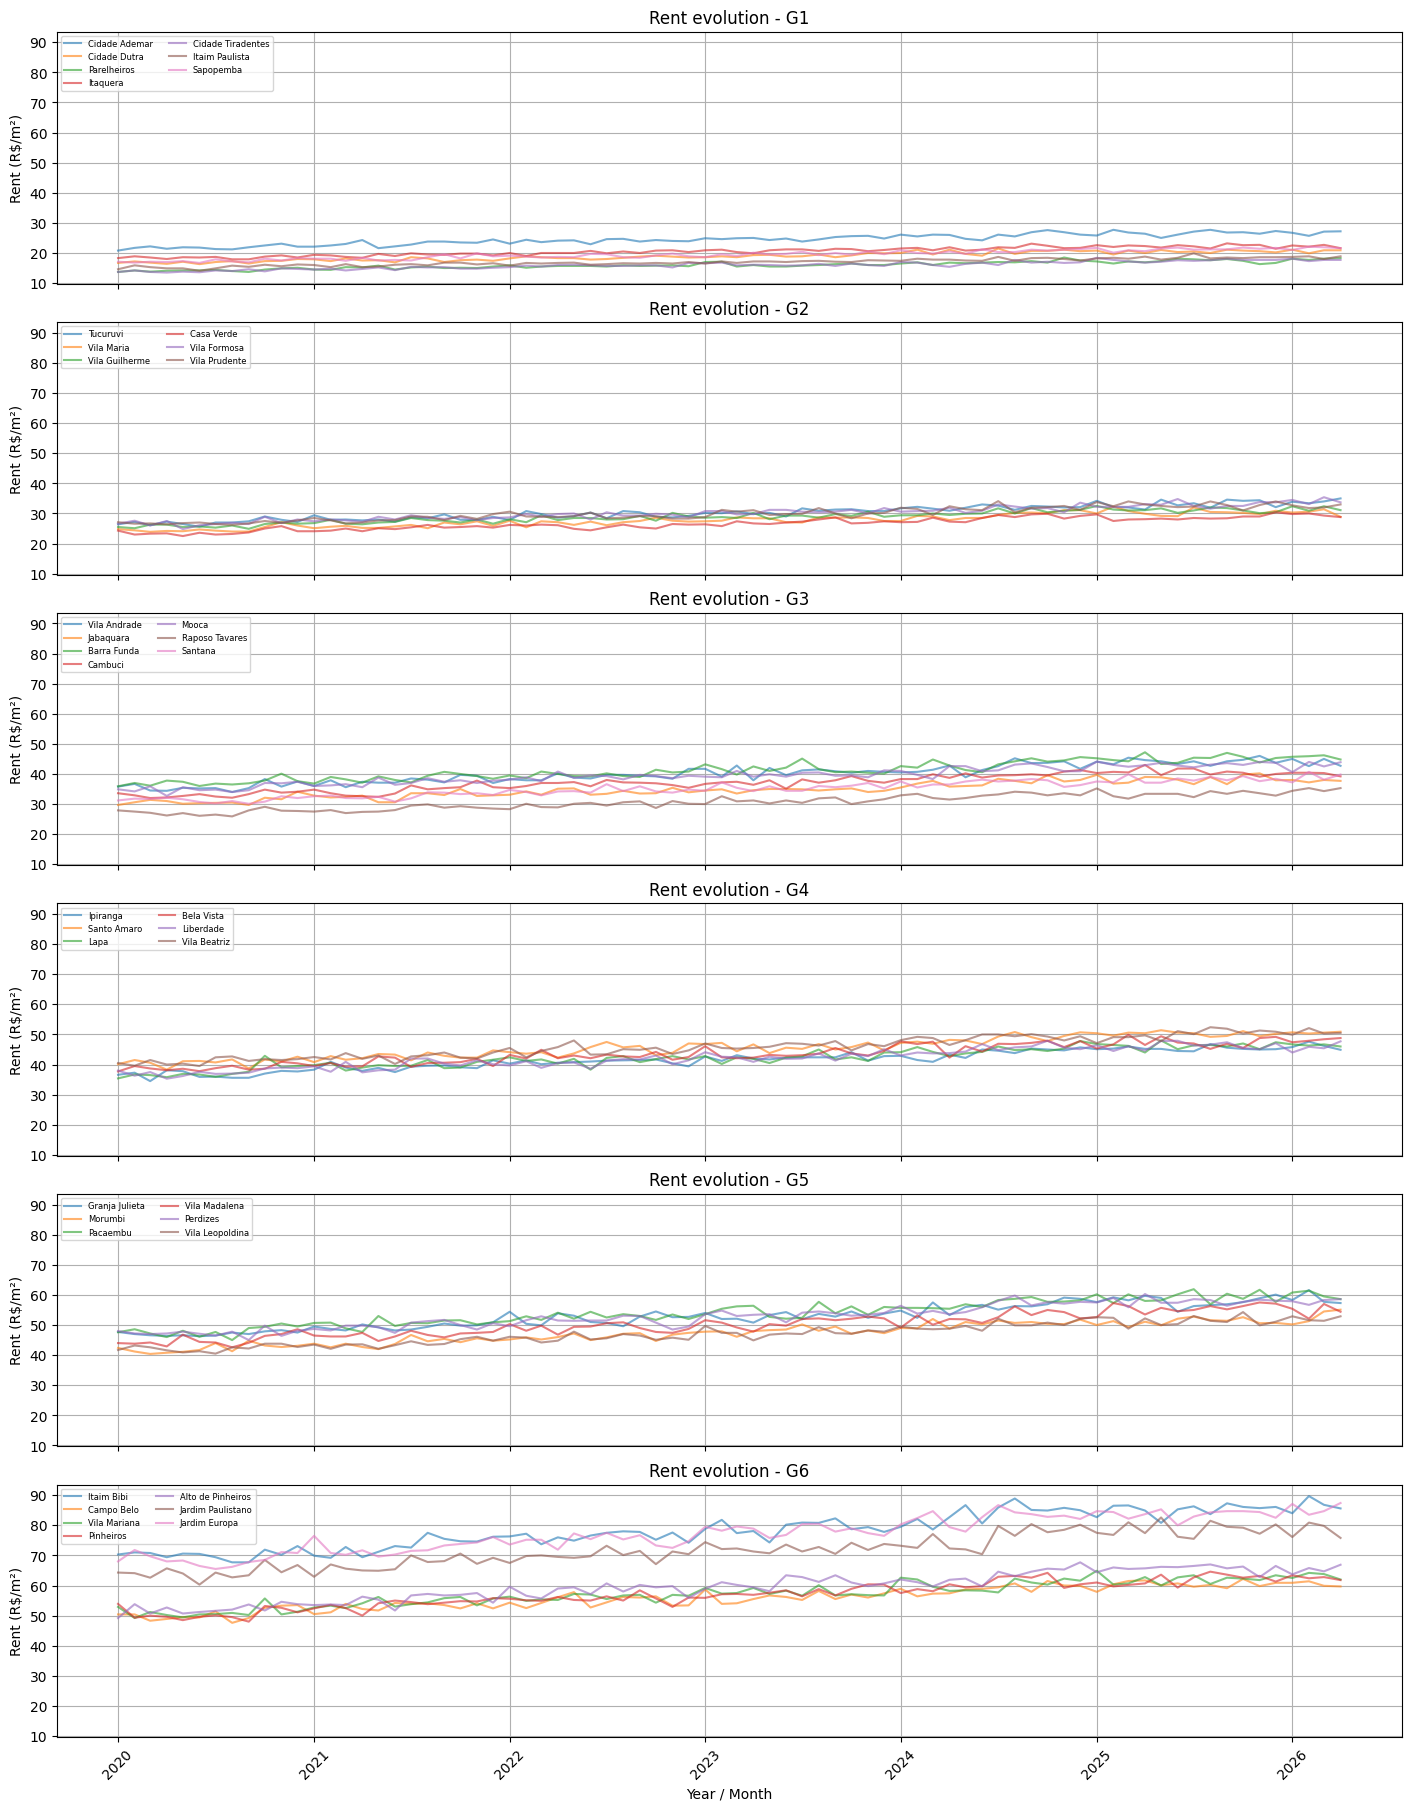

In [34]:
saoPauloModelDf["year_month"] = pd.to_datetime(saoPauloModelDf["year_month"])

bairro_mean_rent = (
    saoPauloModelDf.groupby("neighborhood_name")["rent_per_m2_monthly_brl"]
    .mean()
    .sort_values()
)

n_groups = 6

bairro_groups = pd.qcut(
    bairro_mean_rent,
    q=n_groups,
    labels=[f"G{i+1}" for i in range(n_groups)]
)

bairro_group_map = bairro_groups.to_dict()

saoPauloModelDf["rent_group"] = saoPauloModelDf["neighborhood_name"].map(bairro_group_map)

fig, axes = plt.subplots(
    n_groups,
    1,
    figsize=(14, 3 * n_groups),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

groups = [f"G{i+1}" for i in range(n_groups)]

for i, group in enumerate(groups):

    ax = axes[i]

    group_bairros = saoPauloModelDf[
        saoPauloModelDf["rent_group"] == group
    ]["neighborhood_name"].unique()

    for bairro in group_bairros:
        temp = saoPauloModelDf[saoPauloModelDf["neighborhood_name"] == bairro]

        ts = temp.groupby("year_month")["rent_per_m2_monthly_brl"].mean()

        ax.plot(
            ts.index,
            ts.values,
            alpha=0.6,
            label=bairro
        )

    ax.set_title(f"Rent evolution - {group}")
    ax.set_ylabel("Rent (R$/m²)")
    ax.grid(True)

    ax.tick_params(axis="x", rotation=45)

    ax.legend(fontsize=6, loc="upper left", ncol=2)

axes[-1].set_xlabel("Year / Month")

plt.show()

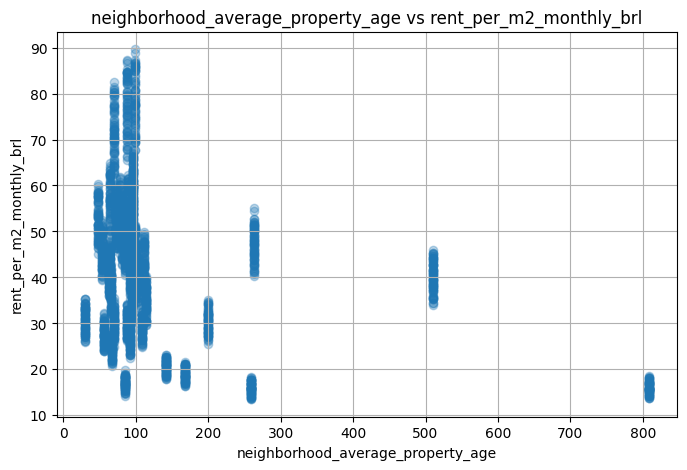

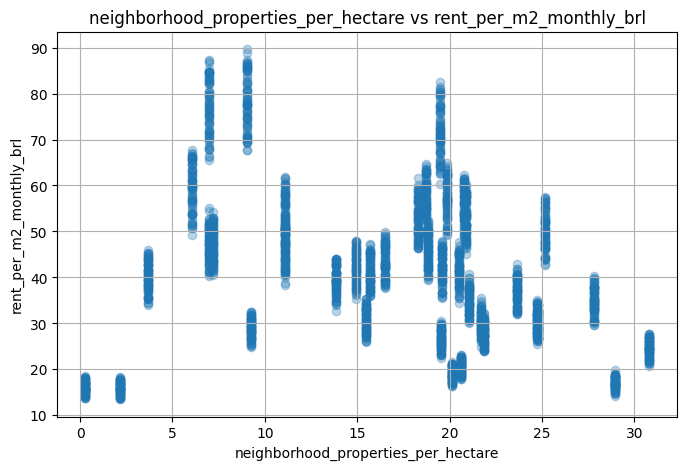

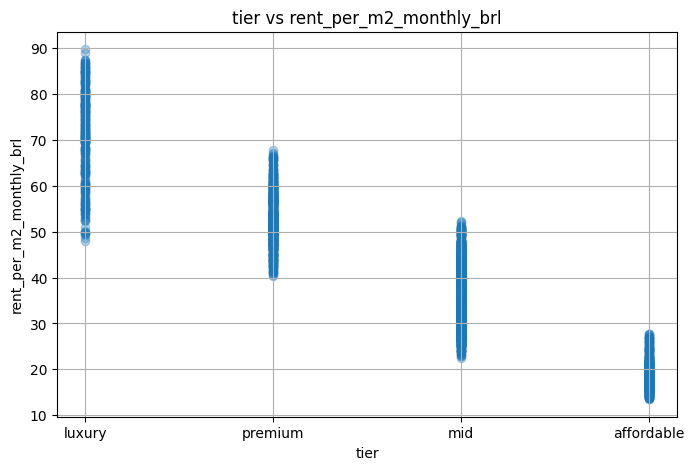

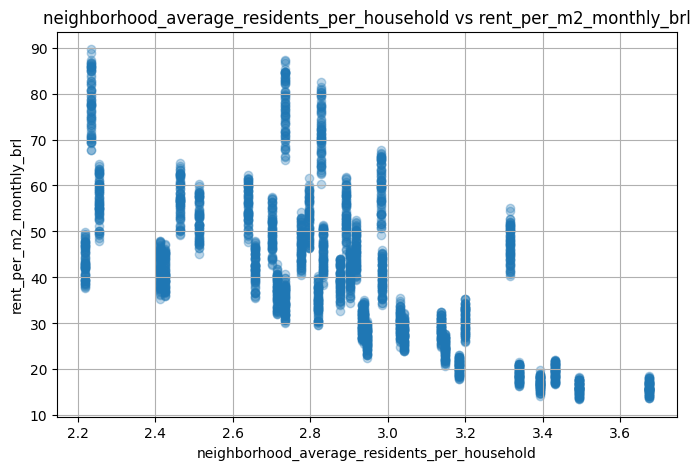

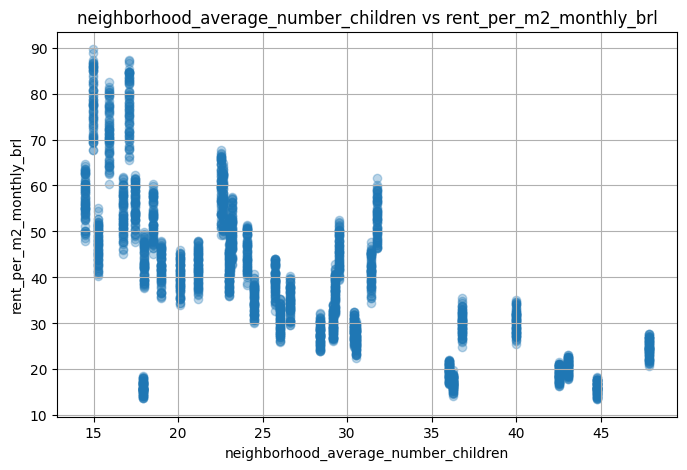

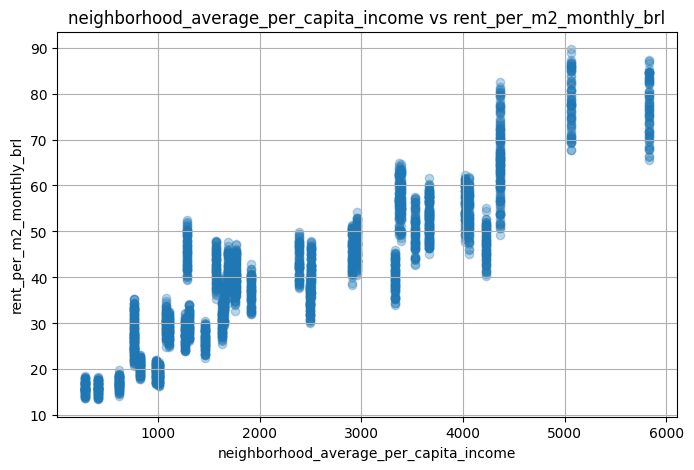

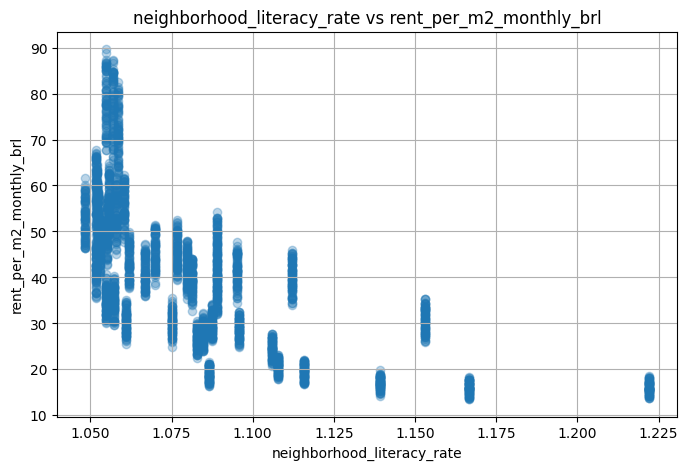

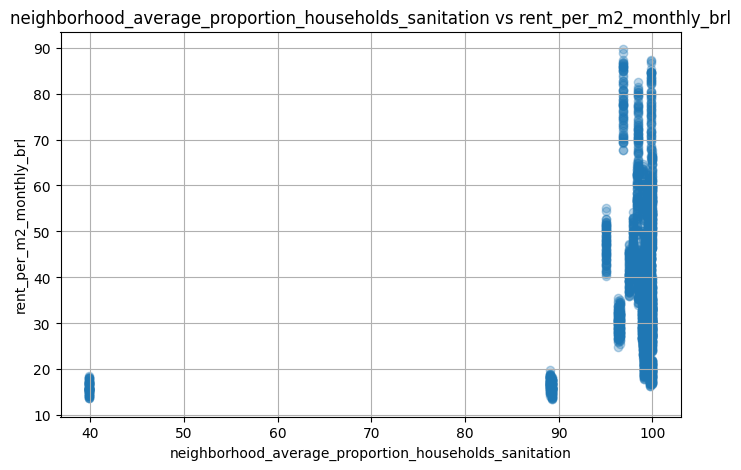

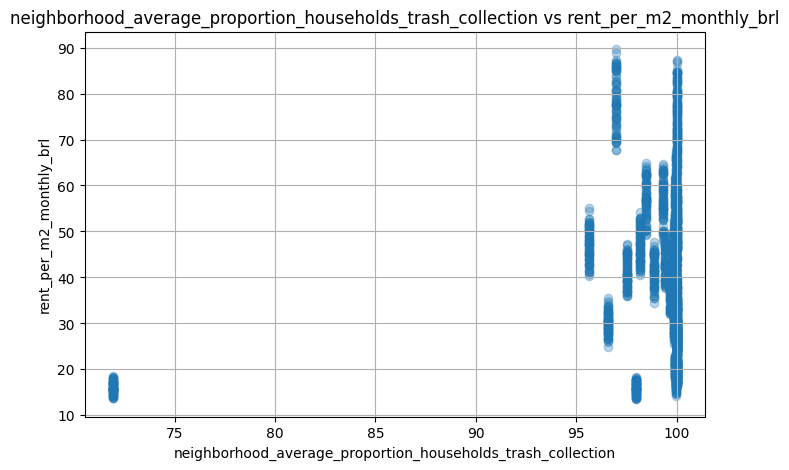

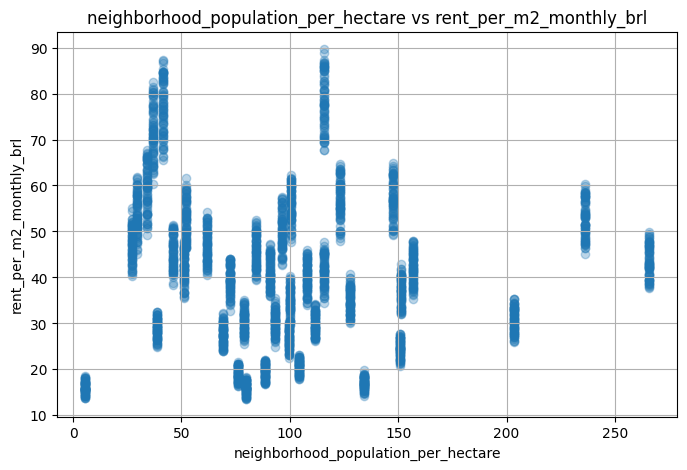

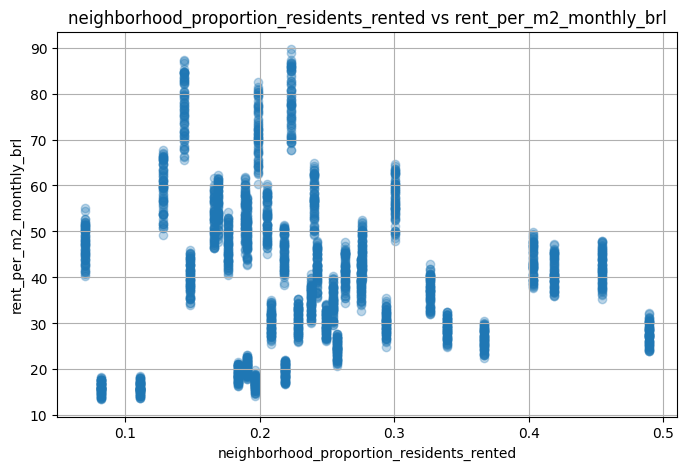

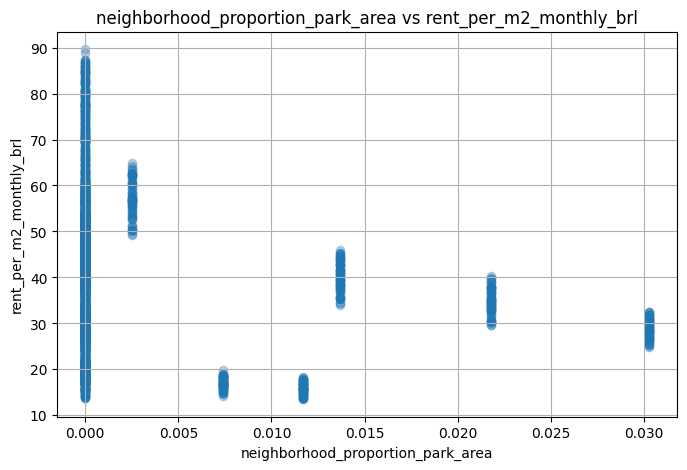

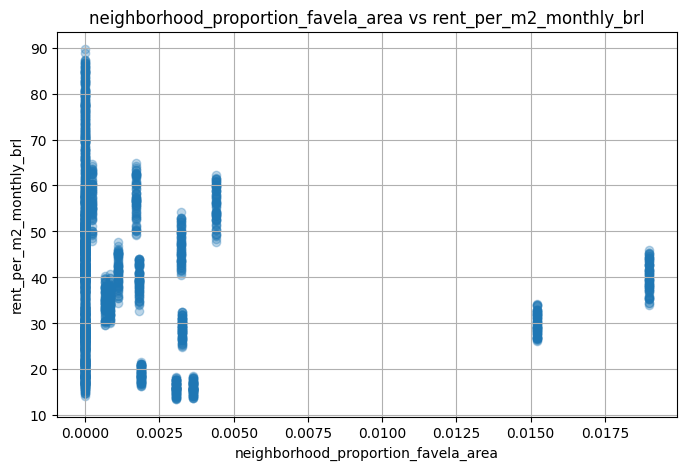

In [35]:
scatter_vs_target(
    saoPauloModelDf,
    "neighborhood_average_property_age"
)

scatter_vs_target(
    saoPauloModelDf,
    "neighborhood_properties_per_hectare"
)

scatter_vs_target(
    saoPauloModelDf,
    "tier"
)


scatter_vs_target(
    saoPauloModelDf,
    "neighborhood_average_residents_per_household"
)

scatter_vs_target(
    saoPauloModelDf,
    "neighborhood_average_number_children"
)

scatter_vs_target(
    saoPauloModelDf,
    "neighborhood_average_per_capita_income"
)

scatter_vs_target(
    saoPauloModelDf,
    "neighborhood_literacy_rate"
)

scatter_vs_target(
    saoPauloModelDf,
    "neighborhood_average_proportion_households_sanitation"
)

scatter_vs_target(
    saoPauloModelDf,
    "neighborhood_average_proportion_households_trash_collection"
)

scatter_vs_target(
    saoPauloModelDf,
    "neighborhood_population_per_hectare"
)

scatter_vs_target(
    saoPauloModelDf,
    "neighborhood_proportion_residents_rented"
)

scatter_vs_target(
    saoPauloModelDf,
    "neighborhood_proportion_park_area"
)

scatter_vs_target(
    saoPauloModelDf,
    "neighborhood_proportion_favela_area"
)

rent_per_m2_monthly_brl


,value
count,2964.000000
mean,40.695850
std,16.326933
min,13.500000
25%,28.400000
50%,40.200000
75%,50.700000
max,89.700000


Missing: 0 (0.00%)
Valores únicos: 653
Outliers (IQR): 32 (1.08%)


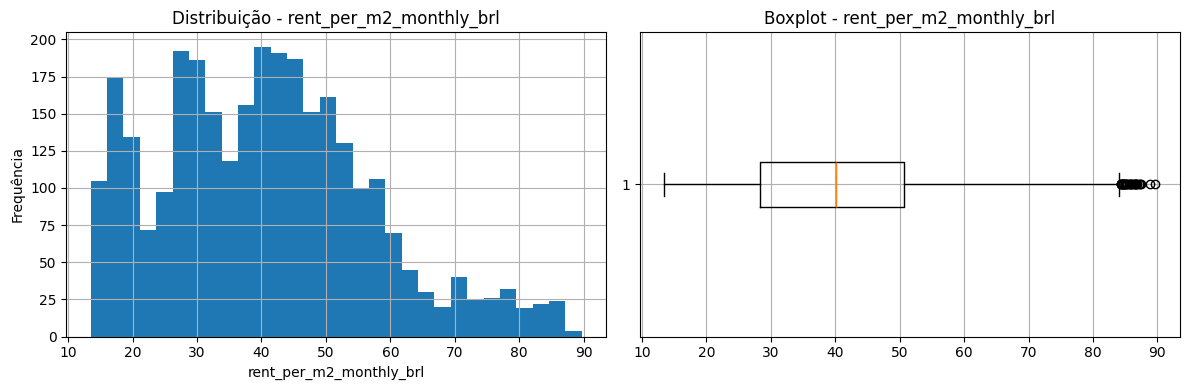

neighborhood_average_property_age


,value
count,2888.000000
mean,128.353932
std,138.605730
min,30.258065
25%,70.132194
50%,90.441064
75%,108.822515
max,808.333807


Missing: 76 (2.56%)
Valores únicos: 38
Outliers (IQR): 456 (15.79%)


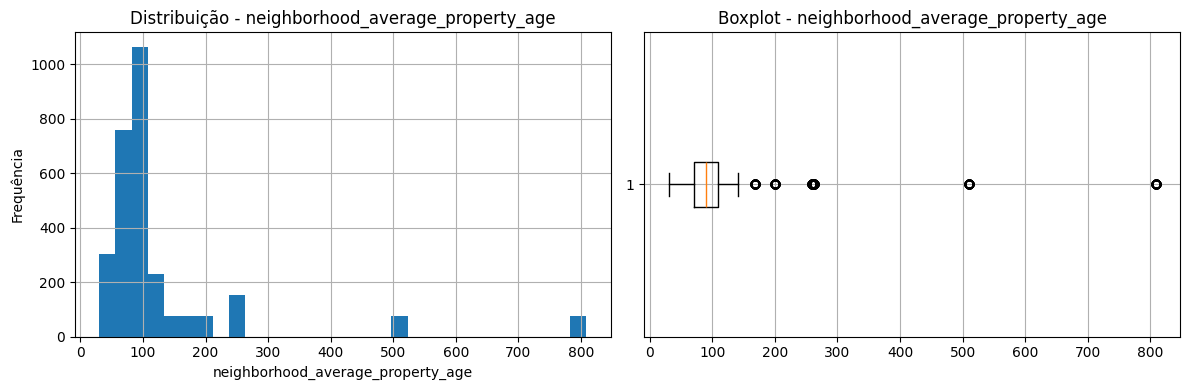

neighborhood_properties_per_hectare


,value
count,2888.000000
mean,16.789943
std,7.520197
min,0.278721
25%,11.071193
50%,19.149261
75%,21.032044
max,30.788297


Missing: 76 (2.56%)
Valores únicos: 38
Outliers (IQR): 0 (0.00%)


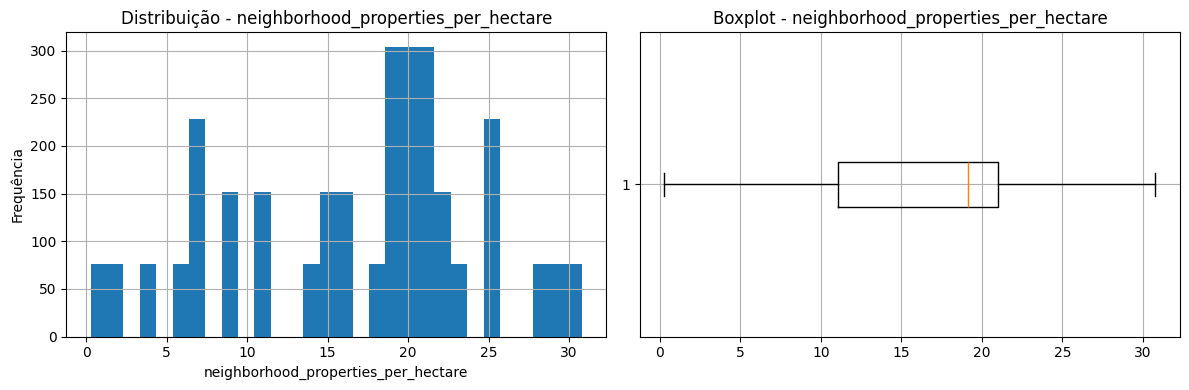

neighborhood_average_residents_per_household


,value
count,2964.000000
mean,2.884861
std,0.343549
min,2.218914
25%,2.700882
50%,2.892500
75%,3.137000
max,3.673433


Missing: 0 (0.00%)
Valores únicos: 39
Outliers (IQR): 0 (0.00%)


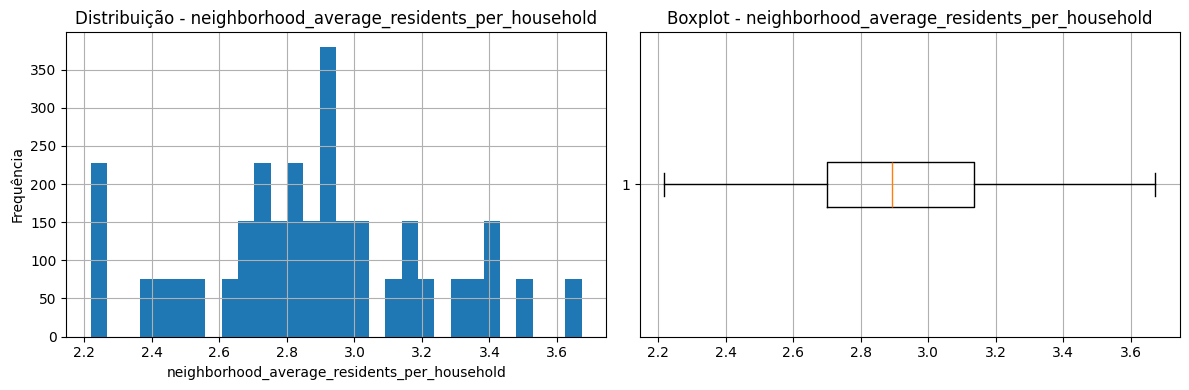

neighborhood_average_number_children


,value
count,2964.000000
mean,26.554251
std,8.917864
min,14.496644
25%,18.490000
50%,24.458333
75%,31.406593
max,47.857143


Missing: 0 (0.00%)
Valores únicos: 39
Outliers (IQR): 0 (0.00%)


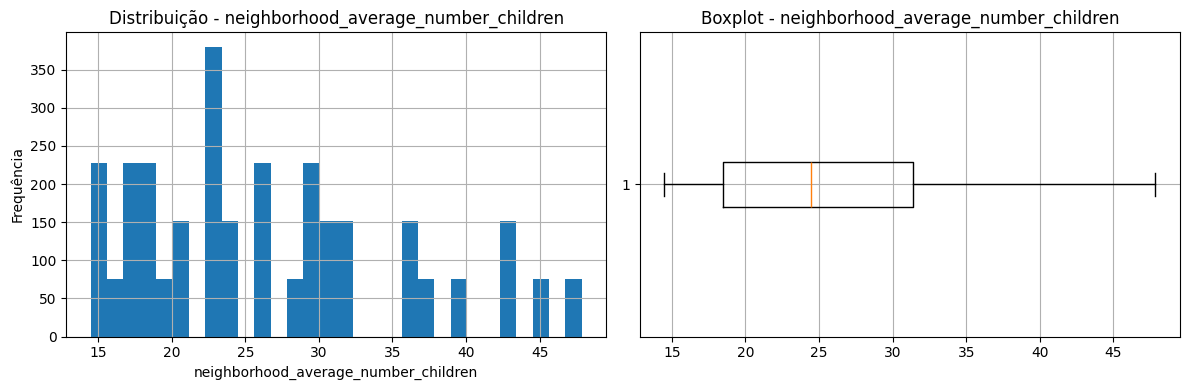

neighborhood_average_per_capita_income


,value
count,2964.000000
mean,2338.747611
std,1412.516528
min,283.053436
25%,1108.490120
50%,1764.033541
75%,3523.381715
max,5827.041633


Missing: 0 (0.00%)
Valores únicos: 39
Outliers (IQR): 0 (0.00%)


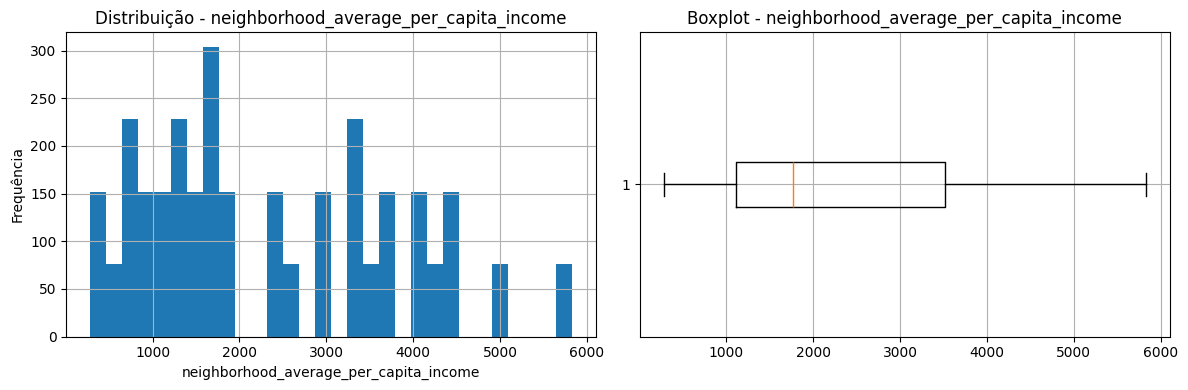

neighborhood_literacy_rate


,value
count,2964.000000
mean,1.082710
std,0.036323
min,1.048411
25%,1.055689
50%,1.075269
75%,1.095100
max,1.222001


Missing: 0 (0.00%)
Valores únicos: 39
Outliers (IQR): 152 (5.13%)


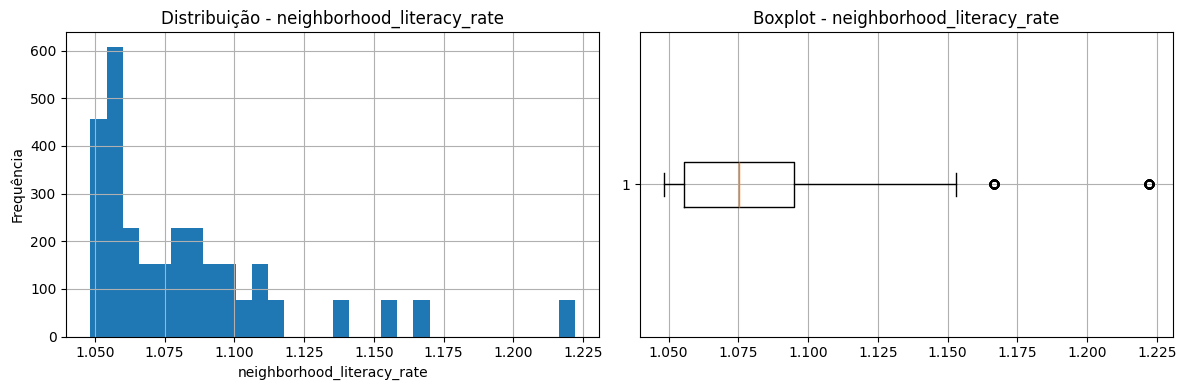

neighborhood_average_proportion_households_sanitation


,value
count,2964.000000
mean,96.953519
std,9.585804
min,39.814067
25%,98.358928
50%,99.232584
75%,99.750500
max,100.000000


Missing: 0 (0.00%)
Valores únicos: 36
Outliers (IQR): 304 (10.26%)


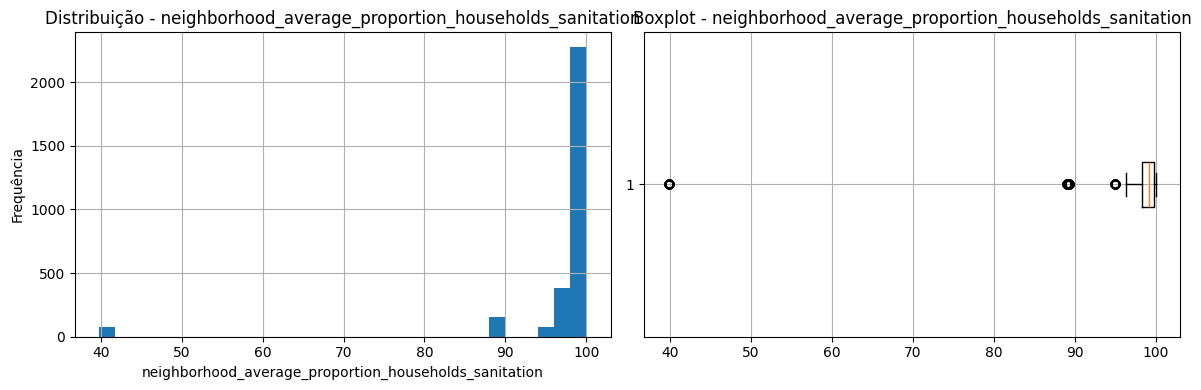

neighborhood_average_proportion_households_trash_collection


,value
count,2964.000000
mean,98.713035
std,4.478879
min,71.912948
25%,99.305685
50%,99.966503
75%,100.000000
max,100.000000


Missing: 0 (0.00%)
Valores únicos: 29
Outliers (IQR): 532 (17.95%)


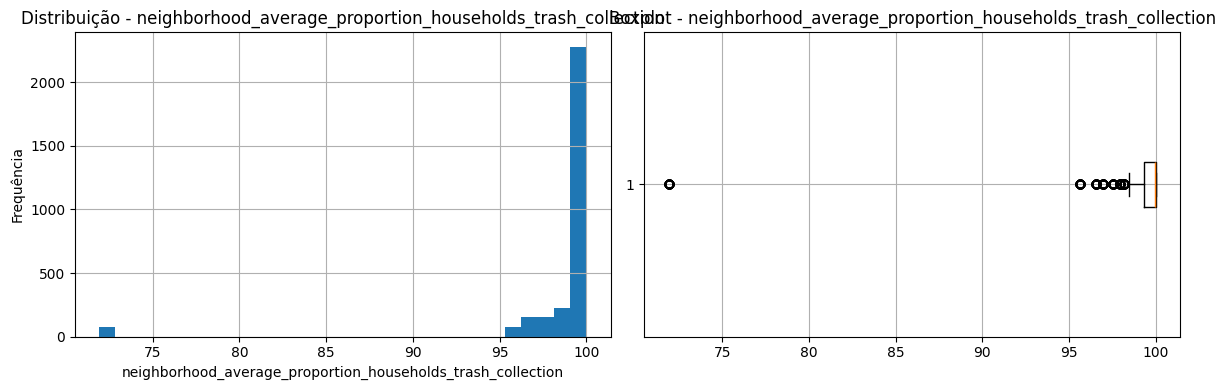

neighborhood_population_per_hectare


,value
count,2964.000000
mean,97.608965
std,54.952715
min,5.604214
25%,52.100854
50%,93.349049
75%,122.965425
max,265.674772


Missing: 0 (0.00%)
Valores únicos: 39
Outliers (IQR): 152 (5.13%)


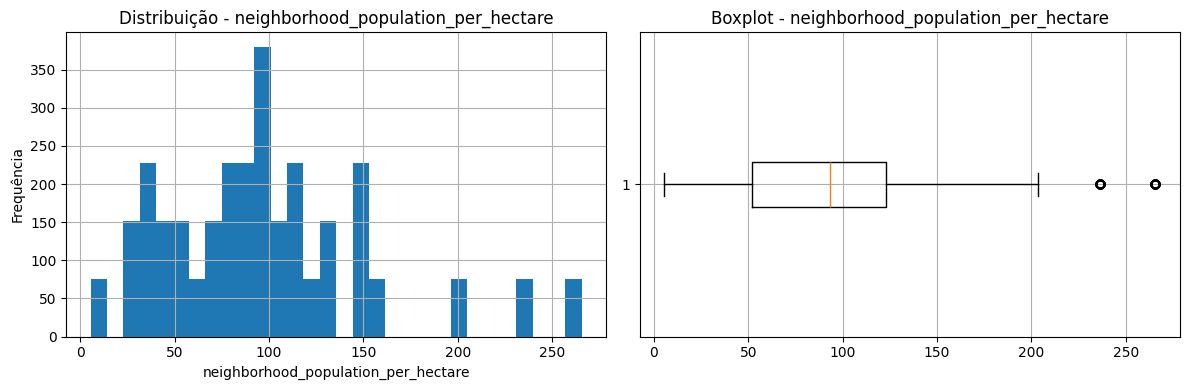

neighborhood_proportion_residents_rented


,value
count,2964.000000
mean,0.239366
std,0.093851
min,0.070249
25%,0.184116
50%,0.223552
75%,0.275998
max,0.489390


Missing: 0 (0.00%)
Valores únicos: 39
Outliers (IQR): 228 (7.69%)


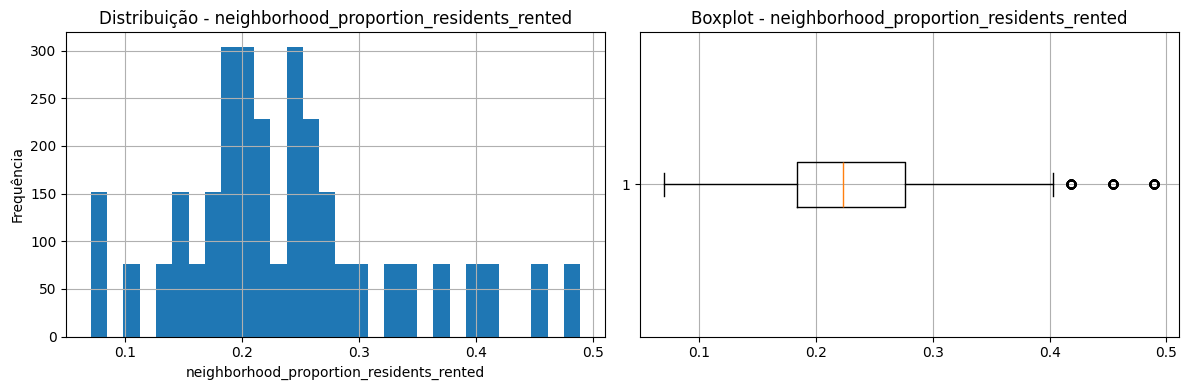

neighborhood_proportion_park_area


,value
count,2964.000000
mean,0.002239
std,0.006367
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.030266


Missing: 0 (0.00%)
Valores únicos: 7
Outliers (IQR): 456 (15.38%)


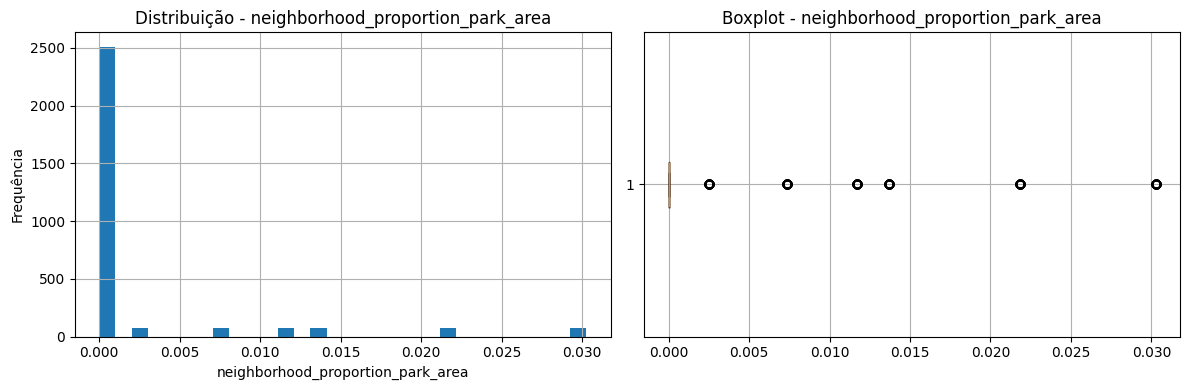

neighborhood_proportion_favela_area


,value
count,2964.000000
mean,0.001537
std,0.003839
min,0.000000
25%,0.000000
50%,0.000000
75%,0.001703
max,0.018978


Missing: 0 (0.00%)
Valores únicos: 15
Outliers (IQR): 228 (7.69%)


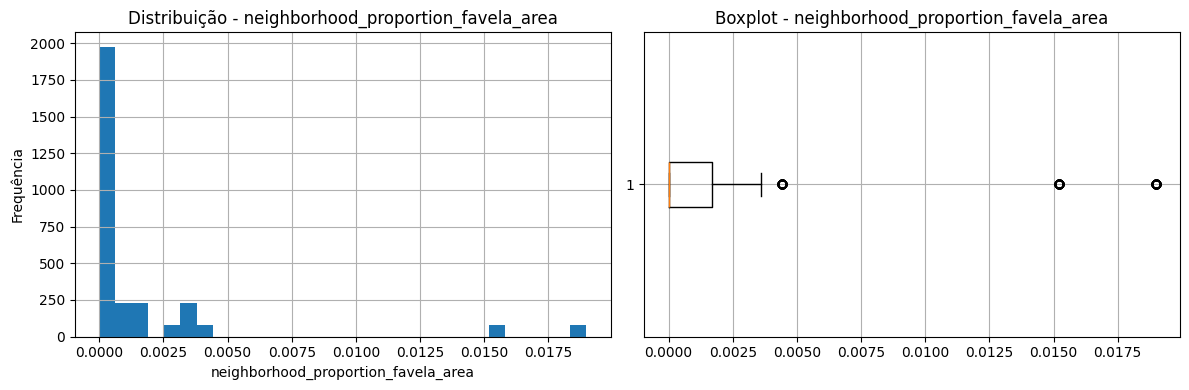

In [36]:
analyze_features(
    saoPauloModelDf,
    "rent_per_m2_monthly_brl"
)

analyze_features(
    saoPauloModelDf,
    "neighborhood_average_property_age"
)

analyze_features(
    saoPauloModelDf,
    "neighborhood_properties_per_hectare"
)

analyze_features(
    saoPauloModelDf,
    "neighborhood_average_residents_per_household"
)

analyze_features(
    saoPauloModelDf,
    "neighborhood_average_number_children"
)

analyze_features(
    saoPauloModelDf,
    "neighborhood_average_per_capita_income"
)

analyze_features(
    saoPauloModelDf,
    "neighborhood_literacy_rate"
)

analyze_features(
    saoPauloModelDf,
    "neighborhood_average_proportion_households_sanitation"
)

analyze_features(
    saoPauloModelDf,
    "neighborhood_average_proportion_households_trash_collection"
)

analyze_features(
    saoPauloModelDf,
    "neighborhood_population_per_hectare"
)

analyze_features(
    saoPauloModelDf,
    "neighborhood_proportion_residents_rented"
)

analyze_features(
    saoPauloModelDf,
    "neighborhood_proportion_park_area"
)

analyze_features(
    saoPauloModelDf,
    "neighborhood_proportion_favela_area"
)

## 4.1 Síntese da análise exploratória

A análise exploratória mostrou que:

- Há uma concentração de bairros em valores mais baixos e poucos bairros com valores elevados. No target, por exemplo, 75% das observações tem aluguel de até aproximadamente 53 reais/m², enquanto o valor máximo chega a cerca de 90 reais/m².
- Também foram observados vários outliers nos dados demográficos. A variável de coleta de lixo, por exemplo, teve 17,95% de outliers, e a proporção de área de favela teve 7,69%. No entanto, essa variação é esperada para o problema, já que diferentes bairros podem apresentar características distintas. Por esse motivo, os outliers não serão removidos.
- A análise também mostrou que algumas variáveis são bem esparsas e tem valores concentrados perto de zero. Por exemplo, na variável de proporção de área de favela, pelo menos 50% das observações têm valor igual a 0, e 75% ficam abaixo de aproximadamente 0,0017 (0,17%)
- As features possuem escalas bem diferentes. Algumas variáveis são proporções próximas de 0, como área de favela, enquanto outras estão em escalas maiores, como população por hectare. Por conta disso, o modelo se beneficiaria com normalização.
- Não foram encontrados valores ausentes relevantes.

Um ponto importante é que, embora exista uma relação entre as caracteristicas demograficas e o preço do aluguel, essa relação pode não ser linear (e.g. a renda pode influenciar o valor do aluguel, mas esse efeito pode ser mais perceptível apenas a partir de determinado nível de renda)

Por conta disso, é necessário avaliar modelos que consigam capturar relações não lineares, além de modelos lineares usados como baseline.

Por fim, uma limitação importante do estudo é que os dados são agregados por bairro, resultando em um número relativamente pequeno de observações e impedindo a modelagem da variabilidade entre imóveis individuais.

# 5. Preparação dos dados e divisão treino/teste

In [37]:
TARGET = "rent_per_m2_monthly_brl"

FEATURES = [
    col
    for col in saoPauloModelDf.columns
    if col not in [
        TARGET,
        "year_month",
        "neighborhood_name",
        "tier",
        "rent_group"

    ]
]

X = saoPauloModelDf[FEATURES]
y = saoPauloModelDf[TARGET]

print(f"Número de features: {len(FEATURES)}")
display(FEATURES)

Número de features: 13


['neighborhood_average_property_age',
 'neighborhood_area_in_hectares',
 'neighborhood_average_residents_per_household',
 'neighborhood_average_number_children',
 'neighborhood_average_per_capita_income',
 'neighborhood_literacy_rate',
 'neighborhood_average_proportion_households_trash_collection',
 'neighborhood_average_proportion_households_sanitation',
 'neighborhood_population_per_hectare',
 'neighborhood_properties_per_hectare',
 'neighborhood_proportion_residents_rented',
 'neighborhood_proportion_park_area',
 'neighborhood_proportion_favela_area']

In [38]:
train_df = saoPauloModelDf[
    saoPauloModelDf["year_month"].between("2022-01-01", "2025-06-30")
].copy()

test_df = saoPauloModelDf[
    saoPauloModelDf["year_month"].between("2025-07-01", "2026-12-31")
].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print(f"Treino: {len(train_df)} observações")
print(f"Teste : {len(test_df)} observações")

Treino: 1638 observações
Teste : 390 observações


In [39]:
validation_df = pd.DataFrame({
    "train": train_df["neighborhood_name"].value_counts(),
    "test": test_df["neighborhood_name"].value_counts()
}).fillna(0).astype(int).sort_index()

display(validation_df)

,train,test
neighborhood_name,,
Alto de Pinheiros,42,10
Barra Funda,42,10
Bela Vista,42,10
Cambuci,42,10
Campo Belo,42,10
Casa Verde,42,10
Cidade Ademar,42,10
Cidade Dutra,42,10
Cidade Tiradentes,42,10


In [40]:
#verifica se não há vazamento entre treino e teste
assert (
    train_df["year_month"].max()
    < test_df["year_month"].min()
), "Erro: há sobreposição entre treino e teste."

print(f"Primeira data do treino: {train_df['year_month'].min().date()}")
print(f"Última data do treino: {train_df['year_month'].max().date()}")
print(f"Primeira data do teste: {test_df['year_month'].min().date()}")
print(f"Última data do teste: {test_df['year_month'].max().date()}")
print("✅ Separação temporal validada com sucesso.")

Primeira data do treino: 2022-01-01
Última data do treino: 2025-06-01
Primeira data do teste: 2025-07-01
Última data do teste: 2026-04-01
✅ Separação temporal validada com sucesso.


##5.1 Justificativa da divisão

Como o objetivo do projeto é prever o preço do aluguel utilizando dados históricos, a divisão entre treino e teste foi realizada de forma temporal (divisão temporal), utilizando observações mais antigas para treinamento e observações mais recentes para teste, evitando assim o vazamento de informação e reproduzindo um cenário mais próximo da aplicação prática que o modelo teria.


# 6. Pré-processamento e pipeline

Como a análise exploratória não identificou valores ausentes relevantes, não foi necessária a etapa de imputação. Também não foi realizado o tratamento dos outliers, já que estes podem representar características reais dos bairros e sua remoção poderia remover informações relevantes para os modelos.

A padronização foi realizada utilizando o `StandardScaler`, ajustado primeiro o treinamento e depois o conjunto de teste, evitando vazamento.

A padronização foi aplicada a todo o pipeline para manter um único fluxo de pré-processamento, o que garante a preparação dos modelos lineares utilizados como baseline.


In [41]:
#padronização

non_numeric_features = X_train.select_dtypes(exclude="number").columns.tolist()

print(f"Features não numéricas: {non_numeric_features}")

assert len(non_numeric_features) == 0, \
    "Existem features não numéricas no conjunto de treino."

#imputação
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

#mantem formato de dataframe depois da imputação
X_train_imputed = pd.DataFrame(
    X_train_imputed,
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    X_test_imputed,
    columns=X_test.columns,
    index=X_test.index
)

#padronização
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

#mantem formato de dataframe depois da padronização
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("\nPadronização realizada com sucesso.")
print(f"Shape treino: {X_train_scaled.shape}")
print(f"Shape teste : {X_test_scaled.shape}")

Features não numéricas: []

Padronização realizada com sucesso.
Shape treino: (1638, 13)
Shape teste : (390, 13)


## 6.1 Decisões de pré-processamento
- Algumas variáveis que representavam valores absolutos já foram previamente transformadas em proporções durante a preparação da base
- Foi aplicada padronização das features, aplicada primeiro sobre o conjunto treinamento e depois teste, evitando vazamento de informação

# 7. Baseline e modelos candidatos

In [42]:
#baseline de regressão
baseline_regression = DummyRegressor(strategy="median")

#modelos candidatos para prever o preço do aluguel
regression_candidates = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "LightGBM": LGBMRegressor(
        random_state=SEED,
        verbose=-1
    )
}

#modelos candidatos para clusterização dos bairros. 4 foi escolhido para comparar com tiers que vem do dataset
clustering_candidates = {
    "KMeans_k4": KMeans(
        n_clusters=4,
        random_state=SEED,
        n_init=10
    ),
    "AgglomerativeClustering_k4": AgglomerativeClustering(
        n_clusters=4
    )
}

print("Baseline de regressão:", baseline_regression)
print("Modelos candidatos de regressão:", list(regression_candidates.keys()))
print("Modelos candidatos de clusterização:", list(clustering_candidates.keys()))

Baseline de regressão: DummyRegressor(strategy='median')
Modelos candidatos de regressão: ['LinearRegression', 'Ridge', 'LightGBM']
Modelos candidatos de clusterização: ['KMeans_k4', 'AgglomerativeClustering_k4']


## 7.1 Justificativa dos modelos

- DummyRegressor (baseline): utilizado para verificar se os modelos conseguem superar uma previsão simples baseada na mediana do conjunto de treinamento.
- Regressão Linear: Avalia se as características demográficas apresentam uma relação linear com o preço do aluguel.
- Ridge: semelhante a regressão linear, mas adiciona uma penalização que ajuda o modelo a fazer previsões mais estáveis quando existem muitas variáveis relacionadas entre si.
- LightGBM: modelo baseado em árvores de decisão por gradient boosting, escolhido por sua capacidade de capturar relações não lineares e interações entre as variáveis
- K-Means (k = 4): utilizado para identificar possíveis agrupamentos naturais entre os bairros a partir de suas características demográficas. O valor 4 foi escolhido para comparar com os 4 tiers já existentes no dataset.

# 8. Treinamento e avaliação inicial

In [43]:
#regressão
regression_results = {}
trained_regression_models = {}

t0 = time.time()
baseline_regression.fit(X_train_scaled, y_train)
train_time = time.time() - t0

y_pred = baseline_regression.predict(X_test_scaled)

regression_results["DummyRegressor"] = evaluate_regression(y_test, y_pred)
regression_results["DummyRegressor"]["Train Time (s)"] = round(train_time, 3)

trained_regression_models["DummyRegressor"] = baseline_regression

for name, model in regression_candidates.items():

    t0 = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test_scaled)

    regression_results[name] = evaluate_regression(y_test, y_pred)
    regression_results[name]["Train Time (s)"] = round(train_time, 3)

    trained_regression_models[name] = model

regression_results_df = (
    pd.DataFrame(regression_results)
    .T
    .sort_values("RMSE")
)

display(regression_results_df)


#clusterização
clustering_results = {}
trained_clustering_models = {}

for name, model in clustering_candidates.items():

    t0 = time.time()
    labels = model.fit_predict(X_train_scaled)
    train_time = time.time() - t0

    clustering_results[name] = evaluate_clustering(
        X_train_scaled,
        labels
    )

    clustering_results[name]["Train Time (s)"] = round(train_time, 3)

    trained_clustering_models[name] = model

clustering_results_df = (
    pd.DataFrame(clustering_results)
    .T
    .sort_values("Silhouette", ascending=False)
)

display(clustering_results_df)

,MAE,RMSE,R²,Train Time (s)
LightGBM,2.934851,3.335832,0.963971,0.256
LinearRegression,3.822136,5.404081,0.905445,0.055
Ridge,3.824839,5.406384,0.905364,0.011
DummyRegressor,14.404103,17.859648,-0.032731,0.001


,Silhouette,Davies-Bouldin,Calinski-Harabasz,Train Time (s)
AgglomerativeClustering_k4,0.304504,1.199227,731.449361,0.119
KMeans_k4,0.298769,1.162010,730.218319,0.041


Comparação das métricas de regressão
Interpretação:
- MAE e RMSE: quanto menores, melhor.
- R²: quanto mais próximo de 1, melhor.
- O melhor modelo deve combinar baixo erro (MAE/RMSE) com alto R².


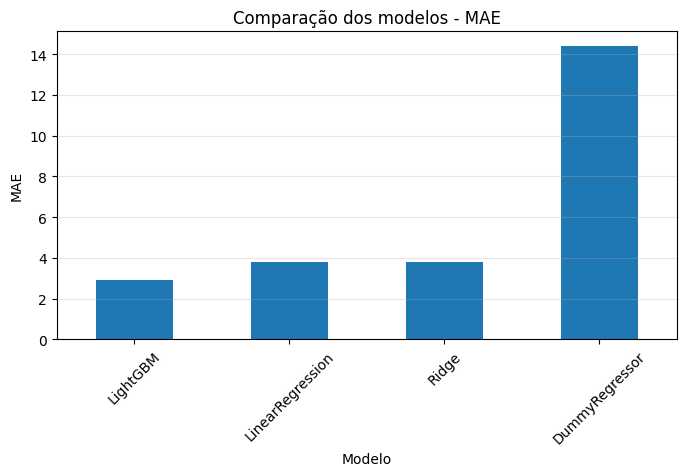

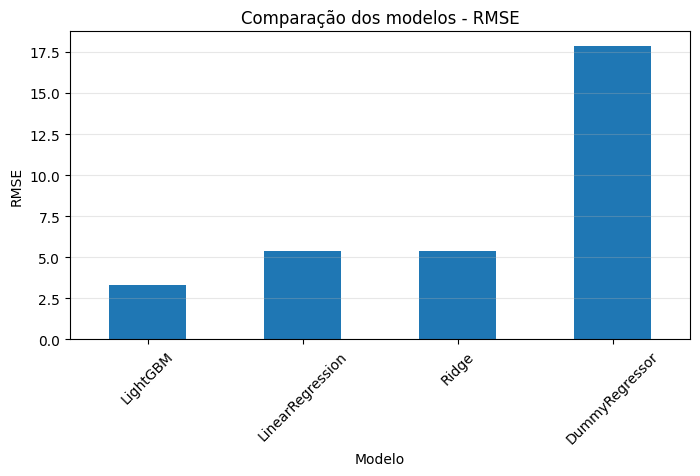

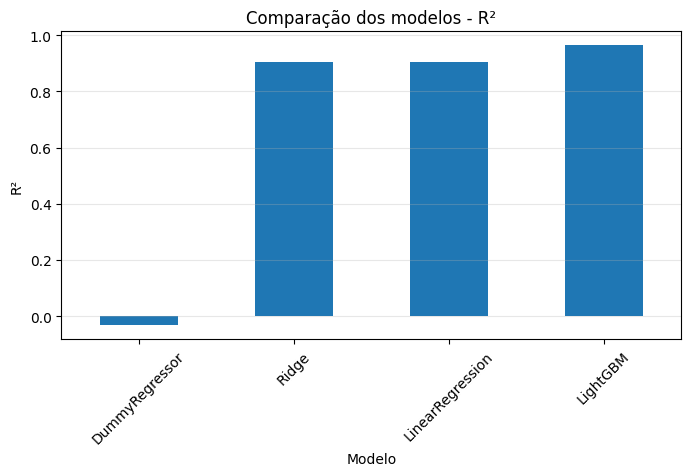

Validação temporal
Interpretação:
- Cada ponto representa o RMSE obtido em um período de validação.
- Linhas mais baixas indicam menor erro.
- Linhas mais estáveis indicam menor variação de desempenho ao longo do tempo.
- A divisão respeita a ordem cronológica dos dados, evitando vazamento de informação.


,LinearRegression,Ridge,LightGBM
Split 1,29.156457,20.090798,20.934597
Split 2,9.374120,8.932845,14.234025
Split 3,9.117253,8.844717,6.097170


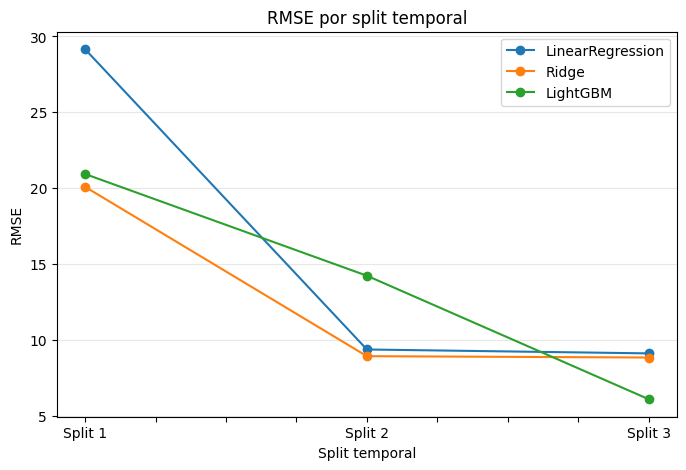

Comparação dos modelos de clusterização
Interpretação:
- Silhouette: quanto maior, melhor.
- Davies-Bouldin: quanto menor, melhor.
- Calinski-Harabasz: quanto maior, melhor.
- O melhor modelo tende a apresentar bom desempenho nas três métricas.


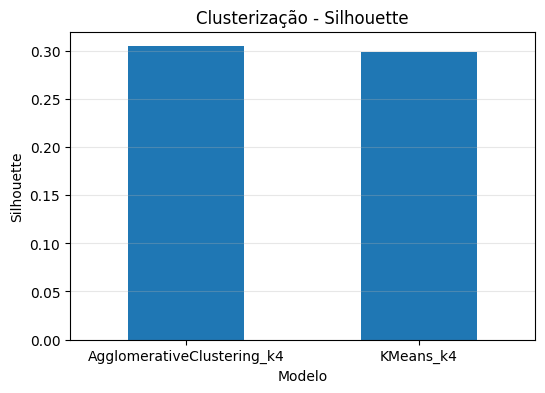

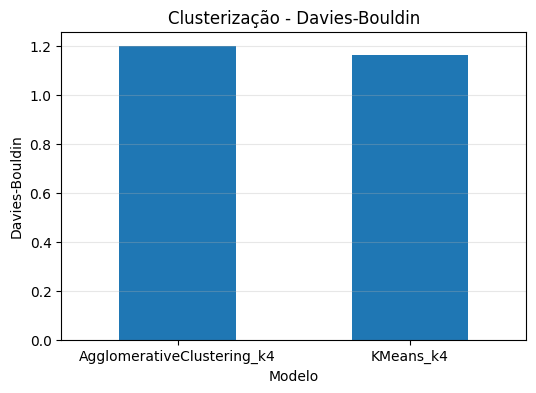

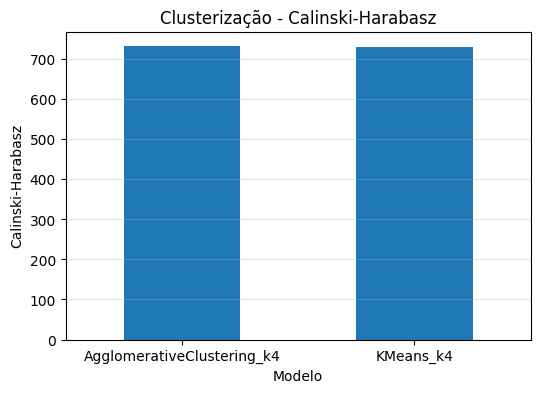

In [44]:
print("=" * 100)
print("Comparação das métricas de regressão")
print("Interpretação:")
print("- MAE e RMSE: quanto menores, melhor.")
print("- R²: quanto mais próximo de 1, melhor.")
print("- O melhor modelo deve combinar baixo erro (MAE/RMSE) com alto R².")
print("=" * 100)

metrics = ["MAE", "RMSE", "R²"]

for metric in metrics:
    regression_results_df[metric].sort_values().plot(
        kind="bar",
        figsize=(8,4)
    )

    plt.title(f"Comparação dos modelos - {metric}")
    plt.ylabel(metric)
    plt.xlabel("Modelo")
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

print("=" * 100)
print("Validação temporal")
print("Interpretação:")
print("- Cada ponto representa o RMSE obtido em um período de validação.")
print("- Linhas mais baixas indicam menor erro.")
print("- Linhas mais estáveis indicam menor variação de desempenho ao longo do tempo.")
print("- A divisão respeita a ordem cronológica dos dados, evitando vazamento de informação.")
print("=" * 100)

tscv = TimeSeriesSplit(n_splits=3)

cv_results = {}

for name, model in regression_candidates.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=tscv,
        scoring="neg_root_mean_squared_error"
    )

    cv_results[name] = -scores

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.index = [f"Split {i+1}" for i in range(len(cv_results_df))]

display(cv_results_df)

cv_results_df.plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("RMSE por split temporal")
plt.ylabel("RMSE")
plt.xlabel("Split temporal")
plt.grid(axis="y", alpha=0.3)
plt.show()

print("=" * 100)
print("Comparação dos modelos de clusterização")
print("Interpretação:")
print("- Silhouette: quanto maior, melhor.")
print("- Davies-Bouldin: quanto menor, melhor.")
print("- Calinski-Harabasz: quanto maior, melhor.")
print("- O melhor modelo tende a apresentar bom desempenho nas três métricas.")
print("=" * 100)

cluster_metrics = [
    "Silhouette",
    "Davies-Bouldin",
    "Calinski-Harabasz"
]

for metric in cluster_metrics:
    clustering_results_df[metric].plot(
        kind="bar",
        figsize=(6,4)
    )

    plt.title(f"Clusterização - {metric}")
    plt.ylabel(metric)
    plt.xlabel("Modelo")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

## 8.1 Análise dos resultados iniciais

- Todos os modelos candidatos para prever o preço médio do aluguel superaram o baseline, indicando que as características demográficas são features relevantes
- O LightGBM apresentou o melhor desempenho em todas as métricas (MAE = 2,93; RMSE = 3,34; R² = 0,964), sugerindo que existem relações não lineares entre as variáveis demográficas e o preço do aluguel
- A validação temporal mostrou que o desempenho do LightGBM melhora ao longo do tempo, enquanto o Ridge apresenta resultados mais estáveis. Isso indica que o desempenho dos modelos pode depender da quantidade de dados históricos disponíveis para tratamento.
- A Regressão Linear e o Ridge apresentaram resultados muito semelhantes, indicando que a variabilidade do preço do aluguel pode ser explicada por relações lineares
- Nenhum dos modelos apresentou indícios de underfitting
- O tempo de treinamento foi inferior a 0,3 s para todos os modelos, mostrando que o custo computacional é baixo e adequado para o tamanho do conjunto de dados
- Na clusterização, K-Means e Agglomerative Clustering apresentaram métricas muito semelhantes, indicando que ambas as abordagens geram agrupamentos consistentes dos bairros.

# 9. Validação e otimização de hiperparâmetros

In [45]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint
from lightgbm import LGBMRegressor

#otimização de hiperparâmetros

N_ITER_SEARCH = 10

cv = TimeSeriesSplit(n_splits=3)

model_to_tune = LGBMRegressor(
    random_state=SEED,
    verbose=-1
)

param_dist = {
    "n_estimators": randint(50, 300),
    "max_depth": randint(3, 10),
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": randint(20, 60)
}

search = RandomizedSearchCV(
    estimator=model_to_tune,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

search.fit(X_train_scaled, y_train)

print(f"Melhor RMSE médio: {-search.best_score_:.3f}")
print("Melhores hiperparâmetros:")
print(search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Melhor RMSE médio: 11.624
Melhores hiperparâmetros:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 157, 'num_leaves': 53}


In [46]:
#modelo otimizado

best_lgbm = search.best_estimator_
best_lgbm.fit(X_train_scaled, y_train)

y_pred = best_lgbm.predict(X_test_scaled)

optimized_results = evaluate_regression(y_test, y_pred)

print(pd.DataFrame(
    {
        "LightGBM Original": regression_results["LightGBM"],
        "LightGBM Otimizado": optimized_results
    }
))

                LightGBM Original  LightGBM Otimizado
MAE                      2.934851            2.934859
RMSE                     3.335832            3.336119
R²                       0.963971            0.963965
Train Time (s)           0.256000                 NaN


## 9.1 Discussão da otimização

- O LightGBM foi escolhido para otimização por ter apresentado o melhor desempenho entre os modelos avaliados, mas a busca por hiperparâmetros não trouxe melhorias sigificativas

# 10. Avaliação final no conjunto de teste

- O LightGBM foi escolhido como modelo final por apresentar o melhor desempenho entre os modelos avaliados.
- O modelo superou o baseline em todas as métricas, indicando que as características demográficas possuem capacidade preditiva para explicar o preço médio do aluguel.
- A análise de resíduos sugere que o modelo foi capaz de compreender os padrões presentes nos dados
- Não foram observados indícios de underfitting, mas a validação temporal mostrou que o desempenho do modelo melhora quando mais dados históricos são utilizados no treinamento.
- A clusterização de bairros apresentou um resultado relativamente bom quando comparada com os tiers originais do dataset. O cluster 1, por exemplo, inclui somente bairros do tier affordable e o cluster 2 consiste em um mix de bairros classificamos como luxury e premium.
- Como limitação, o projeto utiliza dados agregados por bairro, o que resulta em um número menor de observações.

Modelo final: LightGBM


,MAE,RMSE,R²
LightGBM,2.934851,3.335832,0.963971



Comparação com o baseline


,Baseline,Modelo Final
MAE,14.404103,2.934851
RMSE,17.859648,3.335832
R²,-0.032731,0.963971
Train Time (s),0.001000,NaN


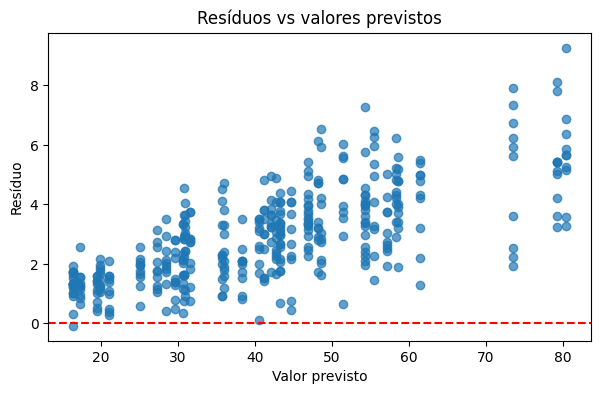

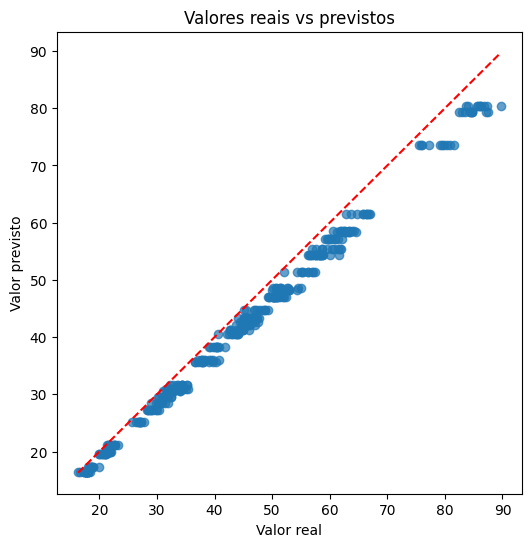

In [47]:
#avaliação final

final_model_name = "LightGBM"
final_model = trained_regression_models[final_model_name]

print(f"Modelo final: {final_model_name}")

y_pred = final_model.predict(X_test_scaled)

final_results = pd.DataFrame(
    [evaluate_regression(y_test, y_pred)],
    index=[final_model_name]
)

display(final_results)

print("\nComparação com o baseline")
display(
    pd.DataFrame(
        {
            "Baseline": regression_results["DummyRegressor"],
            "Modelo Final": evaluate_regression(y_test, y_pred)
        }
    )
)

#resíduos
residuals = y_test - y_pred

plt.figure(figsize=(7,4))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--",
    color="red"
)

margin = 0.5

plt.ylim(
    residuals.min() - margin,
    residuals.max() + margin
)

plt.title("Resíduos vs valores previstos")
plt.xlabel("Valor previsto")
plt.ylabel("Resíduo")

plt.show()

#valores reais vs previstos
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="red"
)

plt.title("Valores reais vs previstos")
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")

plt.show()

Validação da clusterização
Interpretação:
- O objetivo é verificar se os clusters encontrados possuem relação com os tiers existentes no dataset.
- Quanto maior a concentração de um tier em um único cluster, maior a concordância entre as duas segmentações.
- Também são apresentados os perfis médios dos clusters para facilitar sua interpretação.

Tabela de contingência (Tier x Cluster)


cluster,0,1,2,3
tier,,,,
affordable,42,42,0,210
luxury,0,0,168,0
mid,126,0,84,588
premium,0,0,378,0


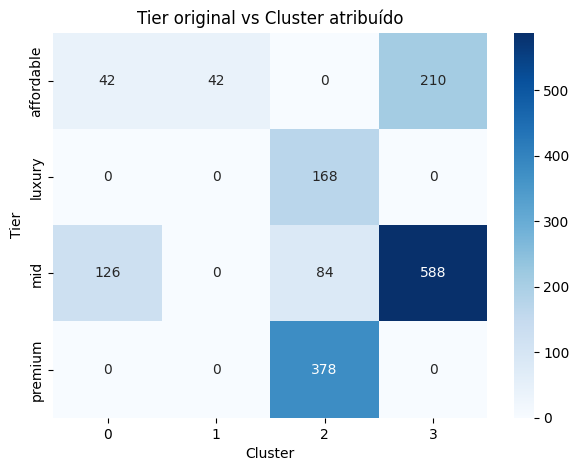

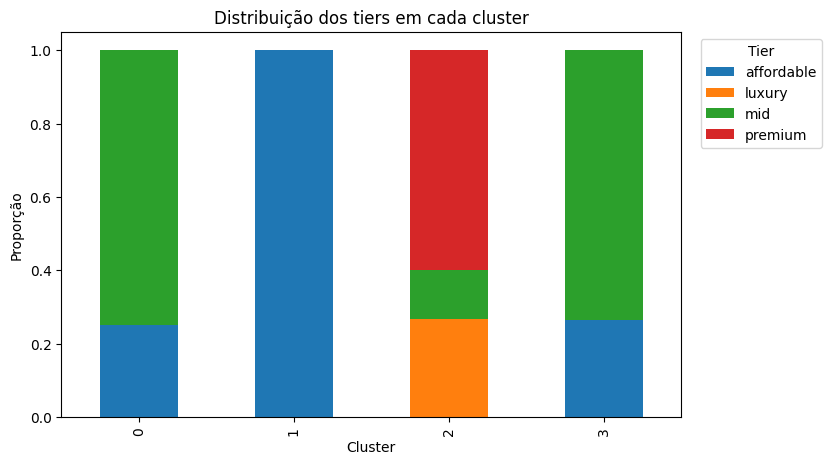


Perfil médio de cada cluster


,neighborhood_average_property_age,neighborhood_area_in_hectares,neighborhood_average_residents_per_household,neighborhood_average_number_children,neighborhood_average_per_capita_income,neighborhood_literacy_rate,neighborhood_average_proportion_households_trash_collection,neighborhood_average_proportion_households_sanitation,neighborhood_population_per_hectare,neighborhood_properties_per_hectare,neighborhood_proportion_residents_rented,neighborhood_proportion_park_area,neighborhood_proportion_favela_area
cluster,,,,,,,,,,,,,
0,241.24,521.25,3.14,31.11,1539.32,1.12,99.47,96.39,84.47,9.96,0.20,0.01,0.01
1,808.33,2852.32,3.67,17.89,283.05,1.22,71.91,39.81,5.60,0.28,0.11,0.00,0.00
2,92.97,304.16,2.71,19.78,3859.21,1.06,99.23,98.92,80.02,14.75,0.19,0.00,0.00
3,94.98,207.11,2.93,31.40,1414.88,1.09,99.56,98.53,119.10,20.93,0.29,0.00,0.00


In [48]:
print("=" * 100)
print("Validação da clusterização")
print("Interpretação:")
print("- O objetivo é verificar se os clusters encontrados possuem relação com os tiers existentes no dataset.")
print("- Quanto maior a concentração de um tier em um único cluster, maior a concordância entre as duas segmentações.")
print("- Também são apresentados os perfis médios dos clusters para facilitar sua interpretação.")
print("=" * 100)

#gera os clusters finais
cluster_model = trained_clustering_models["KMeans_k4"]

cluster_df = train_df.copy()
cluster_df["cluster"] = cluster_model.predict(X_train_scaled)

#comparação entre tier e cluster
comparison = pd.crosstab(
    cluster_df["tier"],
    cluster_df["cluster"]
)

print("\nTabela de contingência (Tier x Cluster)")
display(comparison)

#heatmap
plt.figure(figsize=(7,5))

sns.heatmap(
    comparison,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.title("Tier original vs Cluster atribuído")
plt.xlabel("Cluster")
plt.ylabel("Tier")

plt.show()

#distribuição dos tiers por cluster
cluster_distribution = pd.crosstab(
    cluster_df["cluster"],
    cluster_df["tier"],
    normalize="index"
)

cluster_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Distribuição dos tiers em cada cluster")
plt.xlabel("Cluster")
plt.ylabel("Proporção")

plt.legend(title="Tier", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.show()

#perfil médio dos clusters
print("\nPerfil médio de cada cluster")

cluster_profile = (
    cluster_df
    .groupby("cluster")[FEATURES]
    .mean()
    .round(2)
)

display(cluster_profile)

## 10.1 Análise de erros e limitações

- Os modelos foram treinados apenas com dados geoespaciais/demográficos de 2022, assumindo que houve pouca ou nenhuma variação ao longo do tempo. Além disso, outros fatores que influenciam o perfil dos bairros não foram considerados.
- Nos modelos que estimaram o preço de aluguéis, os maiores erros ocorrem em bairros com preços médios de aluguel mais elevados, indicando que esses casos são mais difíceis de modelar.
- A validação temporal mostrou que o desempenho do modelo melhora à medida que mais dados históricos são utilizados no treinamento. Como a base é relativamente pequena, sua performance seria melhor com mais pontos de observação.
- Os dados estão agrupados por bairro, impossibilitando capturar variabilidade entre imóveis individualmente.
- Para a clusterização, foram gerados apenas 4 clusters para gerar uma comparação com os tiers existentes. A escolha facilita a interpretação, mas um número diferente de clusters poderia relevar outras segmentações importantes.
- Foi realizada apenas uma seleção manual das variáveis de entrada a partir do conhecimento do problema e observação das features existentes. Não foram aplicadas técnicas automáticas de seleção de atributos.

# 11. Comparação final dos modelos

**Regressão**
| Modelo               |    MAE ↓ |   RMSE ↓ |      R² ↑ | Tempo (s) | Observações                                                             | Selecionado |
| :------------------- | -------: | -------: | --------: | --------: | :---------------------------------------------------------------------- | :---------: |
| DummyRegressor       |    14.40 |    17.86 |    -0.033 |     0.003 | Baseline utilizado como referência                                      |             |
| LinearRegression     |     3.82 |     5.40 |     0.905 |     0.067 | Bom desempenho e alta interpretabilidade                                |             |
| Ridge                |     3.82 |     5.41 |     0.905 |     0.020 | Desempenho semelhante ao LinearRegression e maior estabilidade temporal |             |
| LightGBM             | **2.93** | **3.34** | **0.964** |     0.197 | Melhor desempenho no conjunto de teste                                  |      ✅      |
| LightGBM (otimizado) |     2.93 |     3.34 |     0.964 |         - | Desempenho equivalente ao modelo original                               |             |

**Clusterização**
| Modelo                         | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ | Tempo (s) | Observações                              | Selecionado |
| :----------------------------- | -----------: | ---------------: | ------------------: | --------: | :--------------------------------------- | :---------: |
| K-Means (k=4)                  |        0.299 |        **1.162** |              730.22 | **0.113** | Boa concordância com os tiers do dataset |      ✅      |
| Agglomerative Clustering (k=4) |    **0.305** |            1.199 |          **731.45** |     0.250 | Desempenho muito semelhante ao K-Means   |             |


# 12. Boas práticas e rastreabilidade



**Registro de decisões:**
| Decisão                                                                   | Justificativa                                | Impacto esperado                          |
| ------------------------------------------------------------------------- | -------------------------------------------- | ----------------------------------------- |
| Utilizar `SEED = 10`                                                      | Garantir resultados reproduzíveis            | Mesmos resultados em diferentes execuções |
| Utilizar apenas variáveis demográficas como features                      | São as informações de interesse do estudo    | Modelo alinhado ao objetivo do projeto    |
| Remover colunas de identificação                                          | Não contribuem para a previsão               | Evitar ruído no treinamento               |
| Imputar valores ausentes pela mediana                                     | Método simples e robusto                     | Manter todas as observações               |
| Padronizar todas as variáveis                                             | Facilitar a comparação entre modelos         | Pipeline único para todos os modelos      |
| Divisão temporal (2022–H1/2025 → treino; H2/2025–2026 → teste)            | Simular previsões para períodos futuros      | Evitar vazamento temporal                 |
| Utilizar TimeSeriesSplit (3 splits)                                       | Respeitar a ordem cronológica dos dados      | Validação mais realista                   |
| Testar DummyRegressor, LinearRegression, Ridge e LightGBM                 | Comparar diferentes abordagens de regressão  | Escolher o melhor modelo                  |
| Testar K-Means e Agglomerative Clustering                                 | Comparar dois métodos de clusterização       | Avaliar a qualidade dos agrupamentos      |
| Otimizar apenas o LightGBM                                                | Foi o modelo com melhor desempenho inicial   | Verificar possíveis ganhos de desempenho  |
| Buscar apenas `n_estimators`, `max_depth`, `learning_rate` e `num_leaves` | Manter a busca simples                       | Reduzir o tempo de treinamento            |
| Manter o LightGBM original como modelo final                              | A otimização não trouxe melhorias relevantes | Simplificar a solução                     |
| Utilizar RMSE como métrica principal                                      | Penaliza erros maiores                       | Avaliar melhor a qualidade das previsões  |
| Utilizar Silhouette, Davies-Bouldin e Calinski-Harabasz                   | Avaliar diferentes aspectos da clusterização | Comparação mais completa                  |
| Comparar os clusters com os tiers do dataset                              | Validar os grupos encontrados                | Facilitar a interpretação dos clusters    |


# 13. Conclusão

- O objetivo deste MVP foi desenvolver um modelo capaz de prever o preço médio do aluguel dos bairros da cidade de São Paulo a partir de características geoespaciais e demográficas, além de identificar grupos de bairros com perfis semelhantes.
- O LightGBM apresentou o melhor desempenho entre os modelos avaliados, superando o baseline e os demais modelos de regressão. Na clusterização, o K-Means produziu agrupamentos consistentes e coerentes com os tiers existentes no dataset.
- Os resultados confirmaram as hipóteses iniciais, mostrando que as características demográficas possuem capacidade preditiva para explicar o preço médio do aluguel e permitem identificar diferentes perfis de bairros.
- Como principal limitação, o estudo utiliza dados agregados por bairro e um número relativamente pequeno de observações, não capturando a variabilidade entre imóveis individuais nem fatores como infraestrutura, mobilidade e segurança.
- Como melhoria futura, novas variáveis podem ser incorporadas, avaliados outros algoritmos de regressão e clusterização e utilizada uma base mais detalhada para melhorar a capacidade preditiva do modelo.